In [ ]:
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/data_science_do_zero")

# Capítulo 7 - Hipótese e Inferência

Página 125-141

## 7.0 Resumo

**7.1 Teste estatístico de hipóteses**
- Hipótese nula $H_0$ e hipótese alternativa $H_1$
- Significância (erro tipo 1) e Poder do teste (erro tipo 2)
- Teste bilateral e unilateral

**7.2 $p$-valor**
- Mudança de raciocínio: "onde está o corte?" → "quão extremo é esse resultado?"  
  _"Dado $p$ fixo, quão provável é ver esse $X$?"_
- Como interpretar o $p$-valor

**7.3 Intervalo de confiança**
- Outra forma de perguntar: _"dado $X$, quais valores de $p$ são plausíveis?"_

**7.4 Exemplo: executando um teste A/B**
- Comparação de duas proporções
- Estatística $Z$
- Padronização

**7.5 Inferência Bayesiana**
- Mudança de filosofia: $p$ passa a ser a variável aleatória, com incerteza, e expressa por uma distribuição de probabilidade
- Distribuição Beta
- Prior, posterior e conjugação
- Intervalos de confiança

## 7.1 Teste estatístico de hipóteses

### 7.1.1 Exemplo: Lançando uma moeda

Queremos testar a honestidade de uma moeda, sendo assim, a probabilidade $p$ da moeda dar cara deve ser $p = 0,5$.

Então a hipótese nula é $H_0: p = 0,5$ (moeda honesta) e a hipótese alternativa é $H_0: p \neq 0,5$ (moeda viciada), e temos:

$$
\left\{
\begin{array}{ll}
H_0: p = 0,5 \\\\
H_1: p \neq 0,5
\end{array}
\right.
$$

O experimento consiste em jogar a moeda $n$ vezes e contar a quantidade de caras, e esses $n$ lançamentos consistem em uma amostra $X$.

Cada lançamento da moeda é um ensaio de $\text{Bernoulli}(p)$ (função `bernoulli_trial(p)`), então $X$ é uma variável aleatória $\text{Binomial}(n,p)$ (a soma de $n$ lançamentos).

Já vimos que, a medida que $n$ seja grande o suficiente, a $\text{Binomial}(n,p)$ pode ser aproximada por uma função normal em que:

- $\mu = np$
- $\sigma = \sqrt{np(1-p)}$

In [ ]:
from typing import Tuple
import math

# funcao que "define" a funcao normal que sera usada
def normal_approximation_to_binomial(n: int, p: float) -> Tuple[float, float]:
    """
    Retorna mu e sigma correspondentes a aproximacao de binomial(n,p) como normal
    - como a media de Bernoulli(p) eh p
    - binomial(n,p) eh a soma de n trials de Bernoulli(p)
    - entao:
      - media: mu = np
      - desvio padrao: sigma = sqrt(np(1-p))
    """
    mu    = p * n
    sigma = math.sqrt(p * (1 - p) * n)

    return mu, sigma

A `normal_cdf` indica a **probabilidade de uma variável aleatória ser menor ou igual a um determinado valor**. Então, vamos definir algumas funções que serão as ferramentas que nos permitiram testar a hipótese.

In [ ]:
from modulo_python_livro import normal_cdf

# a variavel normal (aleatoria) esta abaixo de um limite?
def normal_probability_below(lo: float, mu: float = 0, sigma: float = 1) -> float:
    """
    Probabilidade de N(mu, sigma) ser MENOR ou igual a lo.
    """
    return normal_cdf(lo, mu, sigma)

# esta acima de um limite?
def normal_probability_above(lo: float, mu: float = 0, sigma: float = 1) -> float:
    """
    Probabilidade de N(mu, sigma) ser MAIOR que lo.
    """
    return 1 - normal_cdf(lo, mu, sigma)

# esta entre dois limites?
def normal_probability_between(lo: float, hi: float, mu: float = 0, sigma: float = 1) -> float:
    """
    Probabilidade de N(mu, sigma) estar entre lo e hi.
    """
    return normal_cdf(hi, mu, sigma) - normal_cdf(lo, mu, sigma)

# esta fora dos limites?
def normal_probability_outside(lo: float, hi: float, mu: float = 0, sigma: float = 1) -> float:
    """
    Probabilidade de N(mu, sigma) NÃO estar entre lo e hi.
    """
    return 1 - normal_probability_between(lo, hi, mu, sigma)

Da mesma forma, podemos inverter e definir ferramentas para **encontrar a região fora do limiar ou o intervalo (simétrico) em torno da média** que está associado a um determinado nível de probabilidade.

In [ ]:
from modulo_python_livro import inverse_normal_cdf

def normal_upper_bound(probability: float, mu: float = 0, sigma: float = 1) -> float:
    """
    Retorna o z para o qual P(Z <= z) = probability
    """
    return inverse_normal_cdf(probability, mu, sigma)

def normal_lower_bound(probability: float, mu: float = 0, sigma: float = 1) -> float:
    """
    Retorna o z para o qual P(Z >= z) = probability
    """
    return inverse_normal_cdf(1 - probability, mu, sigma)

def normal_two_sided_bounds(probability: float, mu: float = 0, sigma: float = 1) -> Tuple[float, float]:
    """
    Retorna os limites simétricos (em torno da média) que contém a probabilidade dada
    """
    tail_probability = (1 - probability) / 2

    # limite superior
    upper_bound = normal_lower_bound(tail_probability, mu, sigma)

    # limite inferior
    lower_bound = normal_upper_bound(tail_probability, mu, sigma)

    return lower_bound, upper_bound

Considerando que serão feitos $n = 1000$ lançamentos e lembrando que a probabilidade de uma moeda honesta é $p = 0,5$, então temos a seguinte **função normal**:

In [ ]:
# aproximacao da distribuicao normal da moeda honesta (p=0.5) com 1.000 lancamentos
n = 1000
p = 0.5 # moeda honesta
mu_0, sigma_0 = normal_approximation_to_binomial(n, p)
print(f"mu_0 = {mu_0:.2f}")
print(f"sigma_0 = {sigma_0:.2f}")

mu_0 = 500.00
sigma_0 = 15.81


### 7.1.2 Significância

Assumindo que $H_0: p = 0,5$ é verdadeira, ou seja, a moeda é honesta, vamos definir a _**significância**_ em $5\%$. Isso significa que:

> _"por puro acaso, mesmo que a moeda seja honesta, estou aceitando que vou rejeitar a hipótese erroneamente em $5\%$ das vezes"_

Esse é o chamado **erro tipo 1** (falso positivo), quando rejeitamos $H_0$ mesmo ela sendo verdadeira. A significância é a probabilidade que tolero cometer esser erro. Ou seja, é uma medida do risco de obter _falso positivo_ que estou disposto a tolerar.

Uma vez definida a significância, a partir dela chegamos no _**nível de confiança**_, que vai permitir encontrar o _**intervalo de confiança**_. O intervalo de confiança estabelece a margem de erro para a métrica testada em que vou aceitar $H_0$.

In [ ]:
significancia = 0.05 # 5%
confianca     = 1 - significancia
print(f"Nível de confiança: {confianca:.0%}")

Nível de confiança: 95%


In [ ]:
# encontra os limites do intervalo de confianca, para significancia de 5%
lower_bound, upper_bound = normal_two_sided_bounds(confianca, mu_0, sigma_0)
print(f"Intervalo de confiança: [{lower_bound:.2f}, {upper_bound:.2f}]")

Intervalo de confiança: [469.01, 530.99]


Considerando que $H_0$ é verdadeira, em $95\%$ das vezes a quantidade de caras obtidas ($X$) vai estar dentro desse intervalo. Há uma probabilidade de $5\%$ de observarmos $X$ fora desse intervalo, e quando isso acontecer, vamos rejeitar $H_0$, mesmo ela sendo verdadeira. Ou seja, para uma significância de $5\%$, o teste indica o resultado correto em 19 de 20 vezes.

### 7.1.3 Poder (_power_)

O _**poder do teste**_ é a probabilidade de não ocorrer um **erro tipo 2** (falso negativo), que acontece quando falhamos na recusa de uma $H_0$ falsa. Ou seja, quando aceitamos uma $H_0$ falsa como verdadeira.

Nesse critério vamos focar na capacidade de detectar que $H_0$ é falsa, quando ela de fato é falsa.

Aqui o raciocínio muda de lado, precisamos especificar o significado de uma $H_0$ falsa, então agora a pergunta é:

> _"Supondo que a moeda seja viciada (digamos, $H_{0'}: p = 0,55$), com que frequência o teste (com o intervalo $[469,531]$ fixado pela significância) vai efetivamente perceber isso?"_

In [ ]:
# aproximacao da distribuicao normal da moeda NAO honesta (p=0.55) com 1.000 lancamentos
p_1 = 0.55 # moeda viciada
mu_1, sigma_1 = normal_approximation_to_binomial(n, p_1)
print(f"mu_1 = {mu_1:.2f}")
print(f"sigma_1 = {sigma_1:.2f}")

mu_1 = 550.00
sigma_1 = 15.73


O **erro tipo 2** ocorre quando falhamos em rejeitar a hipótese nula (sendo que ela é falsa), o que ocorre quando $X$ está dentro do intervalo de confiança (da moeda honesta) definido pela significância.

Se $X$ cair dentro de $[469,531]$, mesmo que a moeda esteja viciada, deixo de rejeitar $H_0$ e isso é um **erro tipo 2**.

O poder do teste é a probabilidade de detectar corretamente que a moeda é viciada, a probabilidade de não ocorrer um **erro tipo 2**:

$$ \text{poder} = 1-P(\text{erro tipo 2})$$

In [ ]:
# intervalo de confianca da moeda honesta e com 5% de significancia
lower_bound, upper_bound

(469.01026640487555, 530.9897335951244)

In [ ]:
# type_2_probability: probabilidade de aceitar H_0 sendo que ela é falsa
# ou seja, probabilidade de X cair no intervalo da moeda honesta, quando ela nao eh honesta
type_2_probability = normal_probability_between(lower_bound, upper_bound, mu_1, sigma_1)
power = 1 - type_2_probability
print(f"P(erro tipo 2): {type_2_probability:.0%}")
print(f"Potência: {power:.0%}")

P(erro tipo 2): 11%
Potência: 89%


O resultado acima mostra que: supondo que $H_{0'}$ seja verdadeira (a moeda é realmente viciada), o teste será capaz de detectar isso em $89\%$ das vezes.

Nos outros $11\%$, $X$ vai cair dentro do intervalo de confiança por puro acaso, mesmo a moeda sendo viciada, e $H_0$ deixará de ser recusada erroneamente (erro tipo 2).



### 7.1.4 Conectando os dois conceitos: _**significância**_ e _**potência**_

Note que os dois conceitos usam o mesmo intervalo $[469,531]$, mas com distribuições diferentes:

- _**significânicia**_ usa a distribuição baseada em $H_0: p = 0,5$, mede o **risco de falso positivo**
- _**potência**_ usa a distribuição sob $H_{0'}: p = 0,55$, mede a **capacidade de detecção real**

Existe um _trade-off_ entre eles:

- **diminuir a _significância_** alarga o intervalo de confiança (diminui a chance de falso positivos) e reduz a potência (fica mais difícil detectar $H_{0'}$ verdadeira, porque o critério ficou mais permissivo)
- **aumentar a significância** estreita o intervalo e aumenta a potência, mas as custas de mais falsos positivos.

#### 7.1.4.1 Diminuindo a _**significância**_ para $1\%$

In [ ]:
significancia_1 = 0.01 # 1%
confianca_1     = 1 - significancia_1
print(f"Nível de confiança (1% de significância): {confianca_1:.0%}")

Nível de confiança (1% de significância): 99%


In [ ]:
print(f"Intervalo de confiança: [{lower_bound:.2f}, {upper_bound:.2f}] (5% de confiança)")

Intervalo de confiança: [469.01, 530.99] (5% de confiança)


In [ ]:
# encontra os limites do intervalo de confianca, para 1% de significancia
lower_bound_1, upper_bound_1 = normal_two_sided_bounds(confianca_1, mu_0, sigma_0)
print(f"Intervalo de confiança: [{lower_bound_1:.2f}, {upper_bound_1:.2f}] (1% de confiança)")

Intervalo de confiança: [459.27, 540.73] (1% de confiança)


In [ ]:
# type_2_probability: probabilidade de aceitar H_0 sendo que ela é falsa, com 1% de significancia
type_2_probability_1 = normal_probability_between(lower_bound_1, upper_bound_1, mu_1, sigma_1)
power_1 = 1 - type_2_probability_1
print(f"P(erro tipo 2): {type_2_probability_1:.0%} (1% de confiança)")
print(f"Potência: {power_1:.0%}")

P(erro tipo 2): 28% (1% de confiança)
Potência: 72%


#### 7.1.4.2 Aumentando a _**significância**_ para $10\%$

In [ ]:
significancia_10 = 0.1 # 10%
confianca_10     = 1 - significancia_10
print(f"Nível de confiança (10% de significância): {confianca_10:.0%}")

Nível de confiança (10% de significância): 90%


In [ ]:
print(f"Intervalo de confiança: [{lower_bound:.2f}, {upper_bound:.2f}] (5% de confiança)")

Intervalo de confiança: [469.01, 530.99] (5% de confiança)


In [ ]:
print(f"Intervalo de confiança: [{lower_bound_1:.2f}, {upper_bound_1:.2f}] (1% de confiança)")

Intervalo de confiança: [459.27, 540.73] (1% de confiança)


In [ ]:
# encontra os limites do intervalo de confianca, para 10% de significancia
lower_bound_10, upper_bound_10 = normal_two_sided_bounds(confianca_10, mu_0, sigma_0)
print(f"Intervalo de confiança: [{lower_bound_10:.2f}, {upper_bound_10:.2f}] (10% de confiança)")

Intervalo de confiança: [473.99, 526.01] (10% de confiança)


In [ ]:
# type_2_probability: probabilidade de aceitar H_0 sendo que ela é falsa, com 10% de significancia
type_2_probability_10 = normal_probability_between(lower_bound_10, upper_bound_10, mu_1, sigma_1)
power_10 = 1 - type_2_probability_10
print(f"P(erro tipo 2): {type_2_probability_10:.0%} (10% de confiança)")
print(f"Potência: {power_10:.0%}")

P(erro tipo 2): 6% (10% de confiança)
Potência: 94%


#### 7.1.4.3 Aumentando uma ordem de grandeza na quantidade de lançamentos

Vamos avaliar como a distância entre as médias, de acordo com cada hipótese, $\mu_0$ e $\mu_{0'}$ cresce em relação a $\sigma$, conforme a quantidade de lançamentos $n$ aumenta.

De acordo com a proximação da Binomial para Normal, temos:

- $\mu = np$
- $\sigma = \sqrt{np(1-p)}$

e a partir disso vemos que **a distância entre as médias $(\mu_0-\mu_{0'})$ cresce linearmente com $n$**:

$$\mu_0 = n \times 0,50$$
$$\mu_{0'} = n \times 0,55$$
$$\text{diferença} = n \times 0,05$$

enquanto o desvio padrão cresce com a raiz de $n$:

$$\sigma \approx \sqrt{n} \times cte$$

Isso significa que, conforme $n$ cresce, a diferença entre as duas médias cresce mais rápido do que a "largura" ($\sigma$) de cada distribuição.

Em outras palavras: as duas curvas normais (de $H_0$ e de $H_{0'}$) vão se separando cada vez mais uma da outra, relativamente à sua própria dispersão.

In [ ]:
# aproximacao da distribuicao normal da moeda honesta (p=0.5) com 10.000 lancamentos
n_ = 10000
p = 0.5 # moeda honesta
mu_0_, sigma_0_ = normal_approximation_to_binomial(n_, p)
print(f"mu_0_ = {mu_0_:.2f}")
print(f"sigma_0_ = {sigma_0_:.2f}")

mu_0_ = 5000.00
sigma_0_ = 50.00


In [ ]:
# encontra os limites do intervalo de confianca da moeda honesta com 5% de significancia
lower_bound_, upper_bound_ = normal_two_sided_bounds(confianca, mu_0_, sigma_0_)
print(f"Intervalo de confiança: [{lower_bound_:.2f}, {upper_bound_:.2f}]")

Intervalo de confiança: [4902.00, 5098.00]


In [ ]:
# aproximacao da distribuicao normal da moeda NAO honesta (p=0.55) com 10.000 lancamentos
p_1 = 0.55 # moeda viciada
mu_1_, sigma_1_ = normal_approximation_to_binomial(n_, p_1)
print(f"mu_1_ = {mu_1_:.2f}")
print(f"sigma_1_ = {sigma_1_:.2f}")

mu_1_ = 5500.00
sigma_1_ = 49.75


In [ ]:
# type_2_probability: probabilidade de aceitar H_0 sendo que ela é falsa, com 5% de significancia
type_2_probability = normal_probability_between(lower_bound_, upper_bound_, mu_1_, sigma_1_)
power = 1 - type_2_probability
print(f"P(erro tipo 2): {type_2_probability:.0%}")
print(f"Potência: {power:.0%}")

P(erro tipo 2): 0%
Potência: 100%


In [ ]:
power

0.9999999999999997

Com $n=1.000$, as curvas de $H_0$ e $H_{0'}$ se sobrepõem bastante (só $3,2 \sigma$ de distância entre as médias), por isso o poder não é tão alto.

Mas com $n=10.000$, elas praticamente não se sobrepõem mais ($10 \sigma$ de distância) e fica quase impossível $X$ cair dentro do intervalo de aceitação de $H_0$ quando a moeda é realmente viciada, então o poder se aproxima de 100%.

In [ ]:
# n=1000
desvios_distancia = round((mu_1 - mu_0) / max(sigma_0, sigma_1), 1)
desvios_distancia

3.2

In [ ]:
# n=10000
desvios_distancia_ = round((mu_1_ - mu_0_) / max(sigma_0_, sigma_1_), 1)
desvios_distancia_

10.0

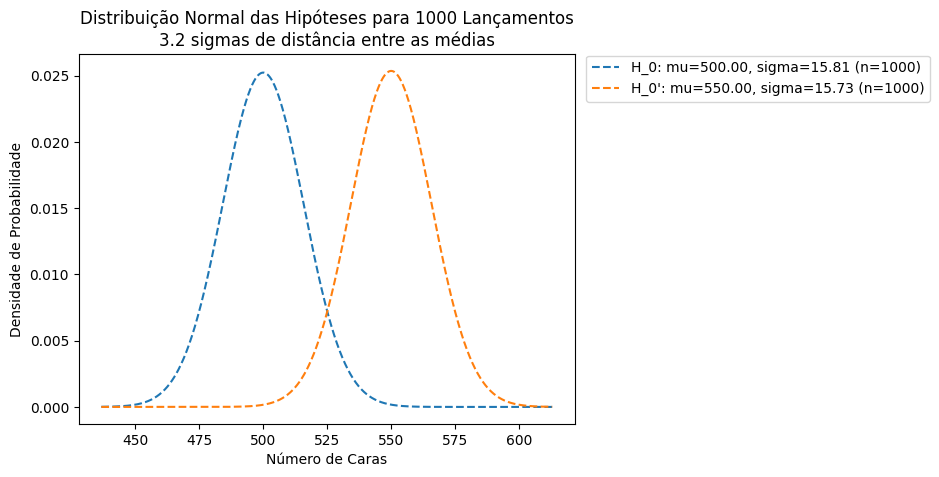

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Calculate the appropriate range for xs to cover all distributions
min_x_val = min(mu_0 - 4 * sigma_0, mu_1 - 4 * sigma_1)
max_x_val = max(mu_0 + 4 * sigma_0, mu_1 + 4 * sigma_1)

# Generate x values for plotting, using numpy.linspace for better control
xs = np.linspace(min_x_val, max_x_val, 1000) # Use 1000 points for smoothness

# Plot the PDF for each hypothesis and trial count using scipy.stats.norm.pdf
plt.plot(xs, norm.pdf(xs, loc=mu_0, scale=sigma_0), '--', label=f"H_0: mu={mu_0:.2f}, sigma={sigma_0:.2f} (n={n})")
plt.plot(xs, norm.pdf(xs, loc=mu_1, scale=sigma_1), '--', label=f"H_0': mu={mu_1:.2f}, sigma={sigma_1:.2f} (n={n})")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.1)
plt.title(f"Distribuição Normal das Hipóteses para {n} Lançamentos\n{desvios_distancia} sigmas de distância entre as médias")
plt.xlabel("Número de Caras")
plt.ylabel("Densidade de Probabilidade")
plt.show()

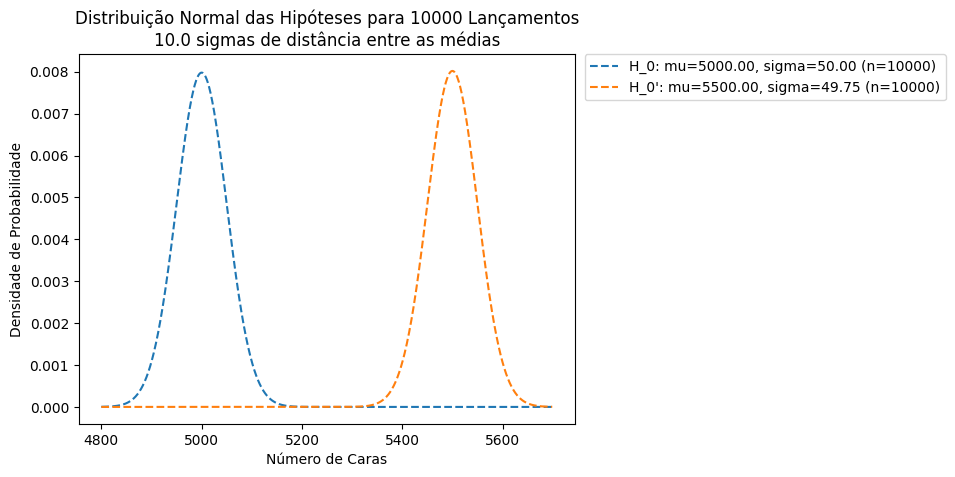

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Calculate the appropriate range for xs to cover all distributions
min_x_val = min(mu_0_ - 4 * sigma_0_, mu_1_ - 4 * sigma_1_)
max_x_val = max(mu_0_ + 4 * sigma_0_, mu_1_ + 4 * sigma_1_)

# Generate x values for plotting, using numpy.linspace for better control
xs = np.linspace(min_x_val, max_x_val, 1000) # Use 1000 points for smoothness

# Plot the PDF for each hypothesis and trial count using scipy.stats.norm.pdf
plt.plot(xs, norm.pdf(xs, loc=mu_0_, scale=sigma_0_), '--', label=f"H_0: mu={mu_0_:.2f}, sigma={sigma_0_:.2f} (n={n_})")
plt.plot(xs, norm.pdf(xs, loc=mu_1_, scale=sigma_1_), '--', label=f"H_0': mu={mu_1_:.2f}, sigma={sigma_1_:.2f} (n={n_})")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.title(f"Distribuição Normal das Hipóteses para {n_} Lançamentos\n{desvios_distancia_} sigmas de distância entre as médias")
plt.xlabel("Número de Caras")
plt.ylabel("Densidade de Probabilidade")
plt.show()

**Resumindo o aumento de lançamentos**

Mais dados não vão reduzir o quanto a moeda é "viciada" (isso é fixo, $p = 0,55$), mas reduz o "ruído" relativo da medição. O desvio padrão cresce mais devagar que a separação real entre as hipóteses.

É por isso que, na prática, testes A/B e experimentos em geral sempre buscam aumentar o tamanho da amostra quando querem detectar efeitos pequenos com confiança.

### 7.1.5 Teste unilateral

No teste anterior (bilateral), a hipótese nula avaliava um valor exato $H_0: p = 0,5$. Qualquer desvio, pra cima ou pra baixo, era evidência contra $H_0$. Por isso o intervalo tinha duas bordas ($[469,531]$) e a significância era divida dos dois lados: $2,5\%$ na cauda de baixo e $2,5\%$ na cauda de cima.

Agora vamos propor uma alteração na natureza de: $H_0: p \le 0,5$. Ou seja, a moeda não é viciada _para cara_, ela pode ser honesta ou até viciada para coroa, mas não pode ser viciada para cara. Nesse caso, $H_0$ só é rejeitado se a moeda parecer viciada **para cara**, ou seja, só um lado do resultado importa.

Abaixo são presentados gráficos em que é possível ver como a _**siginificância**_ ($5\%$) é alocada em cada caso:

mu_0 = 500.0, sigma_0 = 15.81
Bilateral: intervalo de aceitação = [469.0, 531.0]
Unilateral: corte de rejeição = 526.0


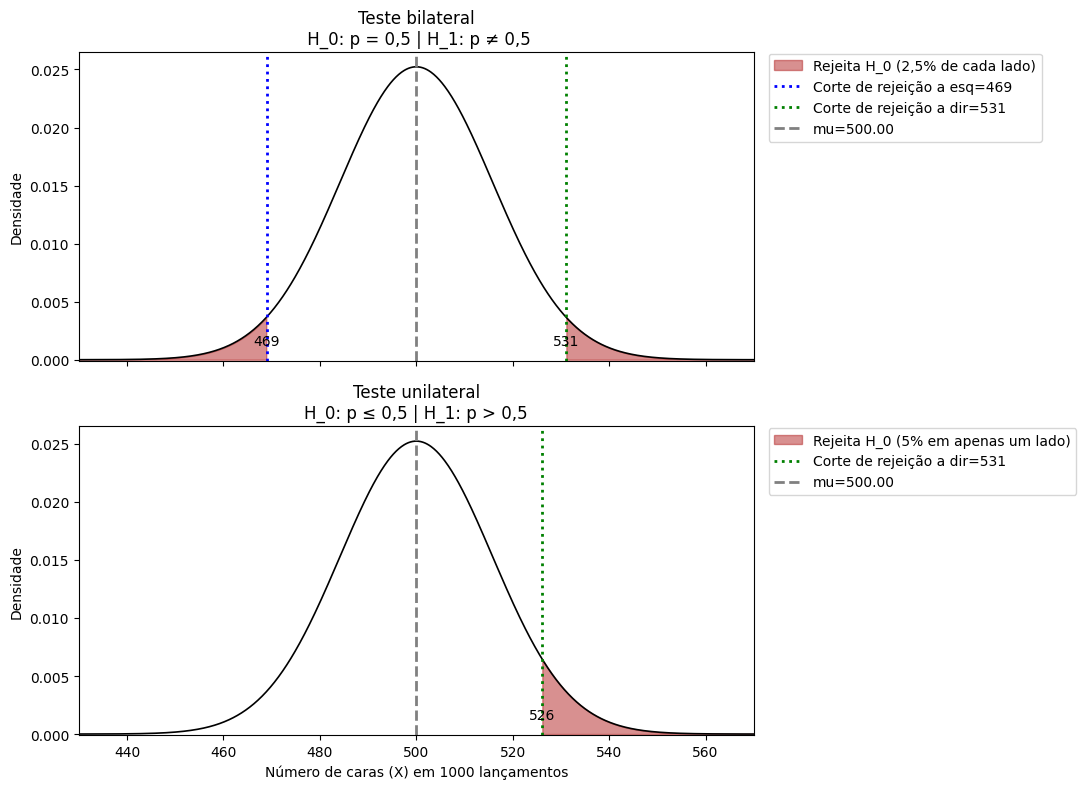

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ---------------------------------------------------------
#    Parâmetros do exemplo
# ---------------------------------------------------------
n = 1000 # qtd lancamentos
p = 0.5 # H0: p = 0,5
mu_0, sigma_0 = normal_approximation_to_binomial(n, p) # normal aproximada

# Bilateral: divide os 5% em duas caudas de 2,5%
lo_bilateral, hi_bilateral = normal_two_sided_bounds(0.95, mu_0, sigma_0)

# Unilateral: os 5% inteiros vão para a cauda de cima (direita)
hi_unilateral = normal_upper_bound(0.95, mu_0, sigma_0)

print(f"mu_0 = {mu_0:.1f}, sigma_0 = {sigma_0:.2f}")
print(f"Bilateral: intervalo de aceitação = [{lo_bilateral:.1f}, {hi_bilateral:.1f}]")
print(f"Unilateral: corte de rejeição = {hi_unilateral:.1f}")


# ---------------------------------------------------------
#    Plot
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

x = np.linspace(mu_0 - 4.5 * sigma_0, mu_0 + 4.5 * sigma_0, 1000)
y = norm.pdf(x, mu_0, sigma_0)

# --- teste bilateral ---
ax1.plot(x, y, color="black", linewidth=1.2)
ax1.fill_between(x, y, where=(x <= lo_bilateral), color="firebrick", alpha=0.5, label="Rejeita H_0 (2,5% de cada lado)")
ax1.fill_between(x, y, where=(x >= hi_bilateral), color="firebrick", alpha=0.5)
ax1.axvline(lo_bilateral, color="blue", linestyle=":", linewidth=2, label=f"Corte de rejeição a esq={lo_bilateral:.0f}")
ax1.axvline(hi_bilateral, color="green", linestyle=":", linewidth=2, label=f"Corte de rejeição a dir={hi_bilateral:.0f}")
ax1.set_title("Teste bilateral\n H_0: p = 0,5 | H_1: p ≠ 0,5")
ax1.text(lo_bilateral, max(y) * 0.05, f"{lo_bilateral:.0f}", ha="center")
ax1.text(hi_bilateral, max(y) * 0.05, f"{hi_bilateral:.0f}", ha="center")

# --- teste unilateral ---
ax2.plot(x, y, color="black", linewidth=1.2)
ax2.fill_between(x, y, where=(x >= hi_unilateral), color="firebrick", alpha=0.5, label="Rejeita H_0 (5% em apenas um lado)")
ax2.axvline(hi_unilateral, color="green", linestyle=":", linewidth=2, label=f"Corte de rejeição a dir={hi_bilateral:.0f}")
ax2.set_title("Teste unilateral\nH_0: p ≤ 0,5 | H_1: p > 0,5")
ax2.text(hi_unilateral, max(y) * 0.05, f"{hi_unilateral:.0f}", ha="center")
ax2.set_xlabel(f"Número de caras (X) em {n} lançamentos")

for ax in (ax1, ax2):
    ax.axvline(mu_0, color="gray", linestyle="--", linewidth=2, label=f"mu={mu_0:.2f}")
    ax.set_ylabel("Densidade")
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.1)
    ax.set_ylim(ymin=-0.0001)
    ax.set_xlim(430,570)

plt.tight_layout()
plt.show()

Se $X$ vier muito **abaixo** de 500, isso não contraria $H_0$ (é até mais consistente com $p \le 0,5$), só $X$ muito **acima** de 500 é evidência contra $H_0$.

In [ ]:
hi = normal_upper_bound(0.95, mu_0, sigma_0)
hi

526.0073585242053

No teste unilateral, como apenas uma cauda importa, os $5\%$ da significância vão pra lá. Isso significa que o corte de cima não precisa mais deixar só $2,5\%$ de probabilidade acima dele, agora deixa $5\%$. E um corte que deixa *mais* probabilidade acima dele, numa curva Normal, fica **mais próximo da média** (não precisa ir tão longe pra "sobrar" mais área na cauda).

Por isso $526 < 531$: o corte fica mais permissivo, mais perto do centro, porque toda a "margem de risco" de 5% está concentrada de um lado só.

Repare: essa função usa só a cauda de cima (não existe mais "lower_bound" nesse teste, porque a cauda de baixo não é usada pra rejeitar nada).

Agora calculamos o erro tipo 2, a probabilidade de $X$ cair dentro da zona de "não rejeição" ($X < 526$) mesmo quando $H_1: p = 0,55$ é verdadeira:

In [ ]:
type_2_probability = normal_probability_below(hi, mu_1, sigma_1)
power = 1 - type_2_probability
power

0.9363794803307173

No teste unilateral, a fronteira relevante ($526$) ficou mais próxima da média e a moeda viciada ($p = 0,55$) empurra $X$ pra cima (exatamente ali, na cauda de cima, onde a capacidade de detecção importa), então fica **mais fácil** para os resultados de $H_1$ (que tendem a valores altos) ultrapassarem esse corte e serem corretamente identificados como "estranhos".

Por isso o poder sobe de $\sim 88\%$ (bilateral) para $93,6\%$ (unilateral): o teste unilateral é mais "afiado" quando você já sabe, de antemão, que só te interessa desvio em uma direção.


## 7.2 $p$-value

Ao trabalhar com os $p$-values mudamos o raciocínio, em vez de pensar _**"onde está o corte"**_, agora avaliamos _**"quão extremo é o resultado que vejo"**_.

O fluxo antes era: decidir a significância → calcular o intervalo/corte → **depois** olhar se $X$ caiu dentro ou fora.

Ao usar o $p$-valor invertemos a ordem lógica: já **temos** o $X$ observado, e perguntamos diretamente: _"supondo $H_0$ verdadeira, qual a probabilidade de ver um resultado tão extremo (ou mais) quanto esse?"_

Isso é matematicamente equivalente ao teste anterior, mas em vez de comparar **$X$ com uma fronteira fixa**, comparamos **uma probabilidade com o nível de significância**. As duas comparações levam à mesma decisão.

Na prática, isso é importante porque com o método do intervalo apenas descobrimos se $X$ está "dentro ou fora". Com o $p$-valor temos acesso a mais informação, sabemos **o quão** dentro ou fora, o que permite justificar _"rejeitaria a $4,2\%$, mas não a $5\%$"_ ou _"rejeitaria com folga, a $2,6\%$"_.

Vamos calcular o teste bilateral de honestidade da moeda. Queremos avaliar a observação de 530 caras:





In [ ]:
def two_sided_p_value(x: float, mu: float = 0, sigma: float = 1) -> float:
    """
    Retorna a probabilidade de ver um resultado tão extremo (ou mais) que x
    """
    if x >= mu:
        # x eh maior do que a media, entao coroa eh qualquer valor maior que x
        return 2 * normal_probability_above(x, mu, sigma)
    else:
        # x eh menor do que a media, entao cara eh qualquer valor menor que x
        return 2 * normal_probability_below(x, mu, sigma)

two_sided_p_value(529.5, mu_0, sigma_0)

0.06207721579598835

In [ ]:
two_sided_p_value(530.5, mu_0, sigma_0)

0.05373218155818327

In [ ]:
import inspect
print(inspect.getsource(normal_probability_above))

def normal_probability_above(lo: float, mu: float = 0, sigma: float = 1) -> float:
    """
    Probabilidade de N(mu, sigma) ser MAIOR que lo.
    """
    return 1 - normal_cdf(lo, mu, sigma)



In [ ]:
print(inspect.getsource(normal_cdf))

def normal_cdf(x: float, mu: float = 0, sigma: float = 1) -> float:
    return (1 + math.erf((x - mu) / math.sqrt(2) / sigma)) / 2



### 7.2.1 Porque multiplica por 2

Dentro de `two_sided_p_value()` multiplicamos por $2$ as probabilidades encontradas por conta da definição de $p$-valor bilateral: _"qual a probabilidade de ver um resultado tão extremo quanto o observado, **em qualquer direção**?"_

Se eu observo $X=530$ (acima da média 500), "tão extremo quanto" não significa só "≥ 530", significa também "um desvio da mesma magnitude para baixo", ou seja, ≤ 470 (porque 530 está 30 acima de 500, e 470 está 30 abaixo). O teste é bilateral porque $H_1: p \ne 0,5$, um desvio pra qualquer lado conta como evidência contra $H_0$.

Como a Normal é **simétrica** em torno de $\mu$, essas duas probabilidades são iguais:

$$ P(X \ge 530) = P(X \le 470) $$

Então, em vez de calcular as duas separadamente e somar, calculamos apenas `normal_probability_above()` e multiplicamos por 2.

### 7.2.2 A correção de continuidade (porquê 529,5)

Estamos aproximando uma variável **discreta** ($X$ só pode ser 0, 1, 2, ..., 1000 caras, não existe "530,3 caras") por uma variável **contínua** (a função Normal possui densidade em qualquer ponto real).

Numa distribuição discreta, $P(X = 530)$ tem massa de probabilidade concentrada exatamente no ponto 530. Numa distribuição contínua, um ponto isolado tem probabilidade zero e só faz sentido falar em **probabilidade de um intervalo**.

Então, pra aproximar _"a chance de dar exatamente 530 caras"_ usando a Normal, pegamos o intervalo $[529.5, 530.5]$, meio ponto pra cada lado, e não $[530, 531]$, que "puxaria" a estimativa pra um lado só.

Por conta da definição de $p$-valor (_"qual a probabilidade de um resultado **tão extremo ou mais do que esse**?"_), na verdade estamos interessados na probabilidade de estar naquela região (530 ou mais extremo, ao menos 530 caras). Portanto, queremos em calcular $P(X \ge 530)$. Como cada inteiro do mundo discreto "empresta" meio ponto pra cada lado quando o representamos numa reta contínua, ao incluir 530 inteiro na soma de probabilidade, o corte na Normal precisa começar me 529.5, a fronteira esquerda.

### 7.2.3 Como interpretar o $p$-valor

Vamos fazer uma simulação para ajudar construir a intuição sobre o significado do $p$-valor.

Vamos rodar 1000 experimentos e em cada experimento faremos 1000 lançamentos de uma moeda honesta ($H_0: p = 0,5$), contando quantos lançamentos "dão cara".

Além disso, para cada experimento vamos avaliar se o resultado (quantidade de caras) é um valor extremo, ou seja, se ficou fora do intervalo de confiança.

Lembrando que: o intervalo de confiança começa a ser calculado a partir do nível de significância ("o quanto" estamos dispostos a cometer um **erro tipo 1**: $H_0$ é verdadeira, mas a rejeitamos mesmo assim). Então, partindo do nível de significância, chegamos ao nível de confiança, onde se concentra o restante dos resultados. Se definimos a significância como $5\%$, então o nível de confiança será de $95\%$:

In [ ]:
# encontra os limites do intervalo de confianca
# para significancia de 5% -> intervalo de confianca concentra 95% dos resultados
lower_bound, upper_bound = normal_two_sided_bounds(0.95, mu_0, sigma_0)
print(f"Intervalo de confiança: [{lower_bound:.3f}, {upper_bound:.3f}]")

Intervalo de confiança: [469.010, 530.990]


Essa simulação busca responder, de forma empírica e sem nenhuma fórmula, a mesma pergunta que o $p$-valor responde de forma analítica: _**"se a moeda for honesta, com que frequência eu veria, só por acaso, um resultado tão estranho quanto 531 caras?"**_

Devemos usar os primeiros valores inteiros fora do intervalo de confiança: 469 e 531.

In [ ]:
import random
np.random.seed(42)

extreme_value_count = 0

# roda 1000 experimentos de uma moeda honesta, H_0: p = 0,5
for _ in range(1000):
    # conta qtd de caras em 1000 lancamentos para cada experimento
    num_heads = sum(1 if random.random() < 0.5 else 0 for _ in range(1000))

    # contabiliza experimentos que o resultado foi um valor extremo
    # valor extremo = fora do intervalo de confianca definido por 5% de significancia
    # no livro nao eh o intervalo de confianca, usa os valores do exemplo que ja estava trabalhando
    if num_heads <= 469 or num_heads >= 531:
        extreme_value_count += 1

print(f"qtd valores extremos: {extreme_value_count}")
print(f"percentual de valores extremos: {extreme_value_count/1000:.2%}")

qtd valores extremos: 47
percentual de valores extremos: 4.70%


Como defini a significância em $5\%$, o $p$-valor (seja calculado analiticamente ou estimado por simulação) me diz: **"se $H_0$ for verdadeira, 5% dos experimentos vão produzir, só por puro acaso, _um resultado tão extremo quanto o que eu observei_"**.

A região abaixo da curva normal que corresponde a esses $5\%$ é tudo aquilo que fica fora do intervalo $[469,531]$. No teste bilateral, essa probabilidade se divide entre as duas caudas, $2,5\%$ para cada lado.

Quando calculo o $p$-valor de um $X$ observado estou calculando _**"quanta área abaixo da curva (nas duas caudas) fica além desse $X$"**_, com isso o resultado pode ser intepretado de duas formas:

- $p$-valor $< 5\%$ → $X$ fora do intervalo (resultado mais extremo) → sobra **menos** de $5\%$ de área para valores mais extremos que $X$ → **tenho evidência para rejeitar $H_0$**
- $p$-valor $> 5\%$ → $X$ dentro do intervalo, mais próximo do centro (média) → sobra **mais** de $5\%$ de área para valores mais extremos que $X$ → **NÃO tenho evidência para rejeitar $H_0$**

Empregamos o mesmo raciocínio com os testes unilaterais. Quando observamos 525 caras:

In [ ]:
normal_probability_above(524.5, mu_0, sigma_0)
# nao recusamos H_0

0.06062885772582072

E quando observamos 527 caras:

In [ ]:
normal_probability_above(526.5, mu_0, sigma_0)
# temos evidencia para recusar H_0

0.04686839508859242

In [ ]:
print(inspect.getsource(normal_probability_above))

def normal_probability_above(lo: float, mu: float = 0, sigma: float = 1) -> float:
    """
    Probabilidade de N(mu, sigma) ser MAIOR que lo.
    """
    return 1 - normal_cdf(lo, mu, sigma)



### 7.2.4 **IMPORTANTE**: verificar normalidade

Todo esse aparato de $p$-valor só é válido **se a aproximação normal for razoável**. No caso da moeda, isso vem do TLC (soma de Bernoullis com n grande). Mas se aplicarmos essas mesmas fórmulas a dados que não têm essa estrutura (por exemplo, distribuições muito assimétricas, com _outliers_ pesados, ou $n$ pequeno), o $p$-valor calculado vai ser **matematicamente correto para uma Normal que não representa os dados**, e a conclusão pode ser completamente enganosa.

## 7.3 Intervalo de confiança

Aqui temos uma mudança de perspectiva: o que antes era fixo, agora é desconhecido, e vice-versa.

Até agora, o fluxo era: **fixamos $p$** (assumimos $H_0: p=0,5$, um valor conhecido), tratamos **$X$ como aleatório** e então perguntávamos: "dado que $p=0,5$, quão provável é este $X$?".

No intervalo de confiança, a lógica se inverte: agora **$X$ já aconteceu** (digamos que observamos 525 caras em 1000 lançamentos, então isso é um fato, não é mais aleatório) e agora **$p$ que é desconhecido**.

A pergunta muda de _"$p=0,5$ é plausível se $X$ acontecer?"_ para "**dado que $X=525$, quais valores de $p$ são plausíveis?**"

A partir do TLC sabemos que a média de variáveis $\text{Bernoulli}(p)$ tem desvio padrão $\sigma = \sqrt{\frac{p(1-p)}{n}}$. O problema dessa fórmula é que **precisa de p**, justamente o que não sabemos mais.

Podemos estimar $p$ de acordo com a quantidade de caras observadas, usando como aproximação $\hat{p} = \frac{525}{1000} = 0,525$, desde que $n$ seja grande e $\hat{p}$ não esteja muito perto de $0$ e $1$.

In [ ]:
# aproximacao normal para experimento que observamos x=525
p_hat = 525 / 1000
mu    = p_hat
sigma = math.sqrt(p_hat * (1 - p_hat) / 1000)

In [ ]:
# calcula intervalo de confianca em torno de p_hat, com 95% de confianca
lower_bound, upper_bound = normal_two_sided_bounds(0.95, mu, sigma)
print(f"Intervalo de confiança: [{lower_bound:.3f}, {upper_bound:.3f}]")

Intervalo de confiança: [0.494, 0.556]


Aplicamos a aproximação normal considerando o $X$ observado e calculamos o intervalo em que o verdadeiro $p$ se encontra com $95\%$ de confiança. Ou seja, _"se o experimento for repetido muitas vezes, em $95\%$ das vezes o parâmetro verdadeiro estará dentro do intervalo de confiança torno do $X$ observado (esse sim vai estar variando ao longo dos experimentos)"_.

Aqui precisamos entender que o que varia ao longo dos experimentos é o intervalo, que estará sempre centrado no valor de $X$ observado. O verdadeiro valor de $p$ é uma constante da moeda, não muda. A aleatoriedade está no intervalo, não em $p$.

Avaliando a hipótese nula $H_0: p=0,5$ quando observamos $X = 525$ caras, o intervalo calculado foi $[0.494, 0.556]$ e **contém** $p=0,5$. Ou seja, não temos evidência para rejeitar $H_0$ e dizer que a moeda é viciada.

Agora vamos calcular o intervalo quando observamos $X=540$ caras:

In [ ]:
# aproximacao normal para experimento que observamos x=540
p_hat = 540 / 1000
mu    = p_hat
sigma = math.sqrt(p_hat * (1 - p_hat) / 1000)

# calcula intervalo de confianca em torno de p_hat, com 95% de confianca
lower_bound, upper_bound = normal_two_sided_bounds(0.95, mu, sigma)
print(f"Intervalo de confiança: [{lower_bound:.3f}, {upper_bound:.3f}]")

Intervalo de confiança: [0.509, 0.571]


Com $X=540$ caras o intervalo calculado foi $[0.509, 0.571]$ e **não contém** $p=0,5$. Ou seja, agora temos evidência para rejeitar a hipótese nula, pois a "moeda honesta" fica fora do intervalo de confiança.

Resumindo:

> "Se o experimento de 1000 lançamentos for repetido muitas e muitas vezes, e em cada repetição for calculado um novo intervalo de confiança de $95\%$ em torno do $\hat{p}$ observado, **95% desses intervalos (diferentes a cada vez) vão conter o verdadeiro $p$ (que é sempre o mesmo)**."

## 7.4 Exemplo: executando um teste A/B

Até o momento, estavamos testando uma única proporção contra um valor fixo, como por exemplo, $p=0,5$.

Agora vamos considerar uma situação em que temos duas proporções, nenhuma delas conhecida a priori, e queremos saber se elas são iguais entre si.

Como ilustração, vamos usar o caso em que temos dois anúncios diferentes para um mesmo produto e queremos definir que anúncio converte mais vendas.

Para isso, executamos um experimento em que exibimos aleatóriamente um dos anúncios e contamos quanto visitantes clicam no anúncio. Os dados que temos são:

- $N_A$: número de pessoas que visualizam o anúncio $\text{A}$
- $n_A$: número de pessoas que clicam no anúncio

Podemos considerar cada visualização como um ensaio de Bernoulli em que $p_A$ é a probabilidade de alguém clicar no anúncio $\text{A}$.

Se $N_A$ é grande, podemos aproximar $p_A=\frac{n_A}{N_A}$ como uma variável aleatória normal com média $p_A$ e desvio-padrão $\sigma_A = \sqrt{\frac{p_A(1-p_A)}{N_A}}$. E da mesma forma aproximamos $p_B=\frac{n_B}{N_B}$ como uma variável aleatória normal com média $p_B$ e desvio-padrão $\sigma_B = \sqrt{\frac{p_B(1-p_B)}{N_B}}$.

Lembrando que, $\text{Bernoulli(p)}$ possui média $p$ e desvio-padrão $\sqrt{p(1-p)}$ ao ser aproximado como uma variável aleatória normal, e segundo o TLC: _"a média das amostras converge para a média da variável original e o desvio padrão é $\frac{\sigma}{\sqrt{N}}$"_.

### 7.4.1 A hipótese nula em termos de uma terceira variável

Queremos saber se um dos anúncios converte mais que o outro, e para isso, podemos avaliar se as duas proporções são iguais entre si, ou seja, queremos testar a hipótese de que _"os dois anúncios são igualmente efetivos"_.

Então, formulamos a seguinte hipótese nula: $H_0: p_B = p_A$, ou ainda, criamos uma terceira variável, "a diferença $(p_B - p_A)$" e verificamos se ela é zero. Dessa forma chegamos a seguinte hipótese nula:

$$H_0: p_B - p_A = 0$$

Quando temos duas variáveis aleatórias normais independentes, para saber qual a distribuição da diferença entre elas, usamos as propriedades básicas da variância:

- a média da diferença é a diferença das médias: $\mu(B-A)=p_B-p_A$
- a variância da diferença é a soma das variâncias: $\text{var}(B-A) = \text{var}(B) + \text{var}(A)$. Lembrando que $\text{var} = \sigma^2$.  
  Quando duas fontes de incerteza independentes são somadas ou subtraídas, elas se acumulam.

Então, a diferença $(p_B - p_A)$ também será normal com média $p_B - p_A$ e desvio-padrão $\sqrt{\sigma^2_{A} + \sigma^2_{B}}$.

### 7.4.2 Padronização

Podemos padronizar a variável $(p_B - p_A)$, para que ela se torne uma _variável normal padrão_, e dessa forma, podemos expressar a diferença em uma escala universal (entre 0 e 1). Então, usaremos o resultado do $z$-score para obter o $p$-valor.

A formulá da variável normal padrão é $Z = \frac{X-\mu}{\sigma}$, e a conta que está sendo feita é:

> _"o que observei ($X$) menos o que esperaria ver se $H_0$ fosse verdade ($\mu$), dividido pelo quanto isso costuma variar por acaso ($\sigma$)"_

- $X - \mu$: é a distância bruta entre os valores observado e esperado (se $H_0$ é verdade)
- $1/\sigma$: reescala essa distância em "unidades de desvio-padrão"

O que o $z$-score me informa é:

> _"quantos desvios-padrão de distância da média $\mu$ (esperada sob $H_0$) está o valor observado $X$"_

Aqui nos lembramos da regra empiríca $\text{"68-95-99,7"}$, que ajudará na intuição sobre os valores do $z$-score. Segundo a regra, cerca de $68\%$ dos resultados caem dentro de $[-\sigma,\sigma]$, $95\%$ em $[-2\sigma,2\sigma]$ e $99,7\%$ em $[-3\sigma,3\sigma]$.

Mas enfim, substibuindo as variáveis na fórmula:

- **valor observado**: $X = \hat{p}_B - \hat{p}_A$
- **valor esperado** (se $H_0$ é verdadeira): $X = p_B - p_A = 0$
- **desvio-padrão da variável observada**: $\sqrt{\sigma^2_{A} + \sigma^2_{B}}$

$$Z = \frac{\hat{p}_B - \hat{p}_A - (p_B - p_A)}{\sqrt{\sigma^2_{A} + \sigma^2_{B}}} = \frac{\hat{p}_B - \hat{p}_A - 0}{\sqrt{\sigma^2_{A} + \sigma^2_{B}}}$$

E finalmente:

$$Z = \frac{\hat{p}_B - \hat{p}_A}{\sqrt{\sigma^2_{A} + \sigma^2_{B}}}$$

Abaixo implementamos essa fórmula do $z$-score em funções Python:

In [ ]:
from typing import Tuple

def estimated_parameters(N: int, n: int) -> Tuple[float, float]:
    p     = n / N
    sigma = math.sqrt(p * (1 - p) / N)
    return p, sigma

def a_b_test_statistic(N_A: int, n_A: int, N_B: int, n_B: int) -> float:
    p_A, sigma_A = estimated_parameters(N_A, n_A)
    p_B, sigma_B = estimated_parameters(N_B, n_B)
    return (p_B - p_A) / math.sqrt(sigma_A ** 2 + sigma_B ** 2)

Vamos voltar ao cenário que citamos no começo para ilustrar a discussão: _"queremos entender se os dois anúncios são igualmente efetivos para converter cliques"_.

Primeiro, vamos considerar o cenário em que **o anúncio $A$ recebeu 200 cliques em 1000 visualizações** e **o anúncio $B$ recebeu 180 cliques em 1000 visualizações**, então a estatística $z$ é:

In [ ]:
# calcula a difenreca das duas distribuicoes em termos de desvios-padrao
z1 = a_b_test_statistic(1000, 200, 1000, 180)
z1

-1.1403464899034472

esse valor fica dentro do intervalo $[-2\sigma,2\sigma]$, o que já nos indica que se trata de um resultado comum, já que está na faixa que cobre $95\%$ dos resultados possíveis.

Mas ainda vamos calcular a probabilidade de observar essa diferença de 20 cliques (ou um resultado tão extremo quanto), se os dois anúncios são igualmente efetivos (ou seja, se $H_0$ é verdade). E ela é dada pelo $p$-valor:

In [ ]:
print(inspect.getsource(two_sided_p_value))

def two_sided_p_value(x: float, mu: float = 0, sigma: float = 1) -> float:
    """
    Retorna a probabilidade de ver um resultado tão extremo (ou mais) que x
    """
    if x >= mu:
        # x eh maior do que a media, entao coroa eh qualquer valor maior que x
        return 2 * normal_probability_above(x, mu, sigma)
    else:
        # x eh menor do que a media, entao cara eh qualquer valor menor que x
        return 2 * normal_probability_below(x, mu, sigma)



In [ ]:
# calcula p-valor na escala padrao, com mu=0 e sigma=1
p_valor1 = two_sided_p_value(z1)
p_valor1

0.2541419765422359

Esse resultado nos diz que se os dois anúncios são igualmente efetivos para converter cliques, em 25% dos casos veríamos uma diferença tão extrema quanto 20 cliques. Ou seja, essa diferença é muito comum, logo, **não rejeitamos $H_0$**.

Por outro lado, vamos considerar também o cenário em que **o anúncio $B$ converteu 150 cliques em 1000 visualizações**, então a estatística $z$ será:

In [ ]:
# calcula a difenreca das duas distribuicoes em termos de desvios-padrao
z2 = a_b_test_statistic(1000, 200, 1000, 150)
z2

-2.948839123097944

Esse resultado se aproxima bastante da fronteira do intervalo $[-3\sigma,3\sigma]$, fora do qual apenas cerca de 0,3% dos casos acontecem. Logo, podemos ver que se trata de um resultado raro.

Calculando a probabilidade de observar essa diferença de 50 cliques, se os dois anúncios são igualmente efetivos, ou seja, se $H_0$ é verdade), encontramos o seguinte $p$-valor:

In [ ]:
two_sided_p_value(z2)

0.003189699706216853

esse $p$-valor confirma que essa diferença de 50 cliques, se os dois anúncios são igualmente efetivos, se trata de um evento bastante raro. Portanto, como $0,003 < 0,05$ (lembrando que estamos adotando 5% como nível de significância) consideramos ter evidência suficiente para rejeitar $H_0$ e assumir que o anúncio $A$ converte mais cliques.

No gráfico abaixo é possível observar os dois cenários do teste A/B, onde as diferenças caem na escala de desvios-padrão:

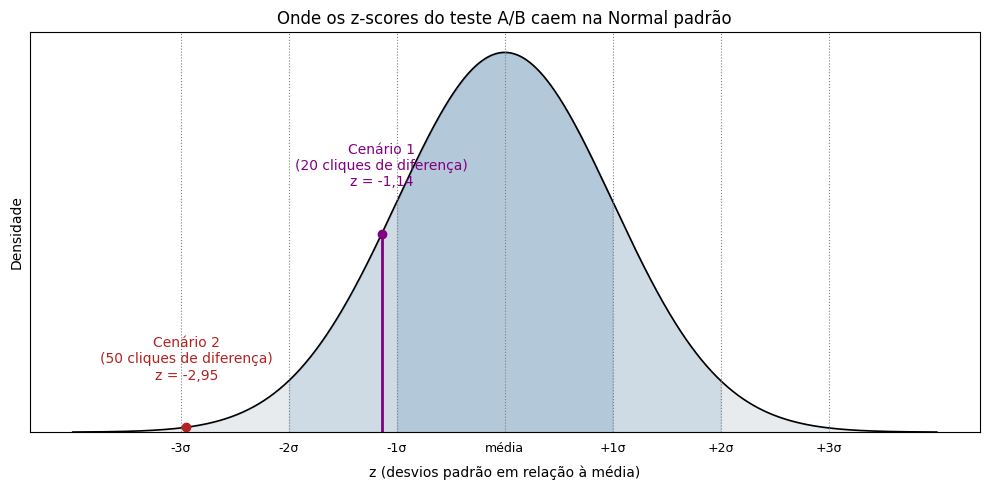

In [ ]:
# curva normal padrao (mu=0, sigma=1)
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, 0, 1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x, y, color="black", linewidth=1.2)
ax.fill_between(x, y, color="lightgray", alpha=0.3)

# faixas de 1, 2 e 3 desvios padrao (regra 68-95-99.7)
for lim, alpha in zip([1, 2, 3], [0.2, 0.15, 0.05]):
    ax.fill_between(x, y, where=(np.abs(x) <= lim), color="steelblue", alpha=alpha)

# linhas verticais nos limites de sigma
for s in [-3, -2, -1, 0, 1, 2, 3]:
    ax.axvline(s, color="gray", linestyle=":", linewidth=0.8)
    label = "média" if s == 0 else f"{s:+d}σ"
    ax.text(s, -0.01, label, ha="center", va="top", fontsize=9)

# marca os dois z-scores dos cenarios
for z, cor, nome in [(z1, "purple", "Cenário 1\n(20 cliques de diferença)\nz = -1,14"),
                      (z2, "firebrick", "Cenário 2\n(50 cliques de diferença)\nz = -2,95")]:
    altura = norm.pdf(z, 0, 1)
    ax.plot([z, z], [0, altura], color=cor, linewidth=2)
    ax.plot(z, altura, "o", color=cor, markersize=6)
    ax.annotate(nome, xy=(z, altura), xytext=(z, altura + 0.05), ha="center", fontsize=10, color=cor)

ax.set_ylim(0, 0.42)
ax.set_xlabel("z (desvios padrão em relação à média)", labelpad=24)
ax.set_ylabel("Densidade")
ax.set_title("Onde os z-scores do teste A/B caem na Normal padrão")
ax.set_yticks([])
ax.set_xticks([])

plt.tight_layout()
plt.show()

Apenas para citar, como aproximamos os valores de $\mu$ e $\sigma$ da distribuição da variável $(p_B - p_A)$, também podemos calcular o $p$-valor direto, sem padronizar a distribuição:

In [ ]:
# calcula p-valor sem padronizar
p_A, sigma_A = estimated_parameters(1000, 200)
p_B, sigma_B = estimated_parameters(1000, 180)

two_sided_p_value(p_B-p_A, mu=0, sigma=math.sqrt(sigma_A**2 + sigma_B**2))

0.2541419765422359

In [ ]:
# p-valor calculado com z-score (padronizado)
p_valor1

0.2541419765422359

## 7.5 Inferência Bayesiana

### 7.5.1 Mudança de filosofia

Até agora, trabalhamos fazendo declarações de probabilidade sobre os testes, como: _"há uma probabilidade de $3\%$ de observar uma estatística tão extrema se a hipótese nula for verdadeira"_. Consideramos $p$ como um valor fixo e desconhecido, tratamos os dados observados como dados aleatórios e perguntamos: _"dado esse $p$ fixo, quão provável é ver estes dados?"_.

Na inferência Bayesiana, **$p$ passa a ser a variável aleatória, vamos falar da incerteza de $p$, expressa por uma distribuição de probabilidade**. Os dados observados serão fixos, usados para atualizar a distribuição de $p$ a medida que temos mais dados. Partimos de uma distribuição priori e vamos atualizando a distribuição posterior conforme mais dados chegam.

### 7.5.2 A distribuição Beta

Quando o parâmetro desconhecido é uma probabilidade (como no caso da moeda), costumamos usar como priori a distribuição Beta.

Ela é conveniente porque coloca todas as probabilidades em $[0,1]$ e seus parâmetros ($\alpha$ e $\beta$) tem uma leitura bastante simples e intuitiva. A função Beta é a integral de Euler de primeiro tipo e pode ser resolvida em termos da função Gama:

$$B(\alpha,\beta) = \int_{0}^{1} t^{\alpha - 1} (1-t)^{\beta - 1} dt = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha + \beta)}$$

E sua função densidade de probabilidade é:

$$f(x;\alpha,\beta) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)}$$

Mas o que realmente faz a função Beta ser a função mais adequada para esse problema é que ela é o prior conjugado (ou conjugada anterior) da Binomial (que é a soma de vários eventos Bernoulli). Isso significa dizer que a posterior, a atualização da distribuição depois de fazer mais medidas (ou observar mais resultados), também será uma Beta. Ou seja, a posterior será uma função fechada e totalmente possível de resolver analíticamente.

Se fosse escolhida outra função para modelar o problema, para resolver a posterior seria necessário calcular a integral do Teorema de Bayes numericamente.

Abaixo definimos funções Python que implementam essas fórmulas:

In [ ]:
def B(alpha, beta):
    """constante normalizadora para que a probabilidade total seja 1"""
    return math.gamma(alpha) * math.gamma(beta) / math.gamma(alpha + beta)

def beta_pdf(x, alpha, beta):
    if x < 0 or x > 1:
        return 0
    if x == 0 and alpha < 1:
        return float('inf')
    if x == 1 and beta < 1:
        return float('inf')
    return x ** (alpha - 1) * (1 - x) ** (beta - 1) / B(alpha, beta)

In [ ]:
# propriedade comutativa
B(1,10) == B(10,1)

True

Vamos plotar alguns exemplos de distribuições Beta para nos ajudar a entender como seus parâmetros funcionam:

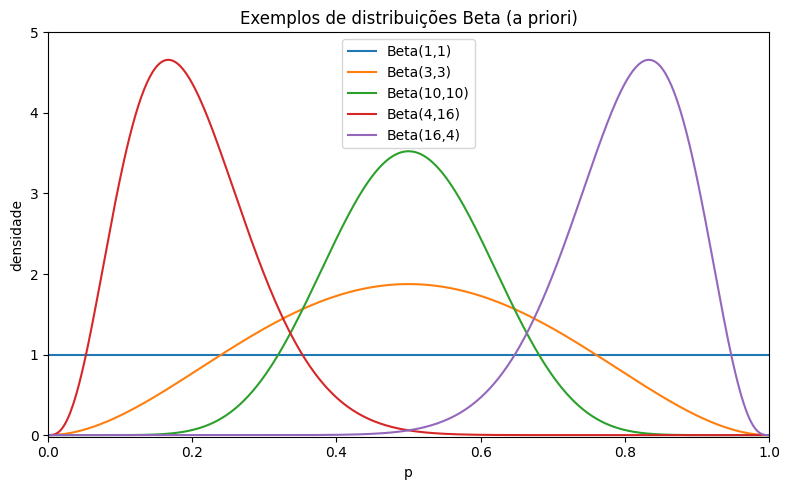

In [ ]:
priors = [(1, 1), (3, 3), (10, 10), (4, 16), (16, 4)]
xs     = np.linspace(0.001, 0.999, 500)

plt.figure(figsize=(8, 5))
for alpha, beta in priors:
    ys = [beta_pdf(x, alpha, beta) for x in xs]
    plt.plot(xs, ys, label=f"Beta({alpha},{beta})")

plt.title("Exemplos de distribuições Beta (a priori)")
plt.xlabel("p")
plt.ylabel("densidade")
plt.legend()
plt.ylim(-0.02,5)
plt.xlim(0,1)

plt.tight_layout()
plt.show()

Note que, quanto maior $\alpha$ em relação a $\beta$, mais o peso empurra pra perto de $1$; e quanto maior $\beta$ em relação a $\alpha$, mais empurra pra perto de $0$. E quanto maiores os dois juntos, mais "concentrada"/estreita fica a curva, repare como $B(10,10)$ é bem mais estreita que $B(1,1)$, mesmo as duas centradas em $0,5$.

### 7.5.3 Cada observação é uma pequena atualização

Ao definir a priori, podemos enxergar $\alpha$ e $\beta$ é como "pseudo-observações": $B(\alpha,\beta)$ se comporta como se você já tivesse visto $\alpha - 1$ caras e $\beta - 1$ coroas:

- $B(1,1)$: nenhuma observação, por isso é uniforme (_"não estou dizendo nada"_)
- $B(30,10)$ = como se tivéssemos visto 29 caras e 9 coroas (_"aqui temos uma crença bem forte de que a moeda pende pra cara"_).

Se a priori (prior/anterior) é $B(\alpha,\beta)$, e observamos $h$ caras e $t$ coroas, a posteriori (posterior) é $B(\alpha+h,\beta+t)$. Estamos somando as observções antigas com as novas, isso torna a Beta um prior conjugado da Binomial: a atualização não exige nenhuma integral complicada, estamos apenas somando contagens.

Cada lançamento de moeda, individualmente, é uma nova informação que desloca e estreita um pouquinho a sua distribuição sobre $p$. Depois de 1 lançamento, você tem uma distribuição. Depois de 2, outra ligeiramente diferente. Depois de 100, outra bem mais estreita. É um processo contínuo, em que $h$ e $t$ são contadores acumulados.

#### 7.5.3.1 Prior uniforme

Vamos simular uma moeda honesta ($p=0,5$) partindo de um prior uniforme $B(1,1)$ e acompanhar a evolução da distribuição de $p$ com "fotos" em diferentes momentos: depois de 5, 20, 100 e 1000 lançamentos.

> Lembrando que, partir do prior $B(1,1)$ significa dizer que: _"não sei nada sobre a moeda, todos os valores de $p$ são igualmente plausíveis"_.

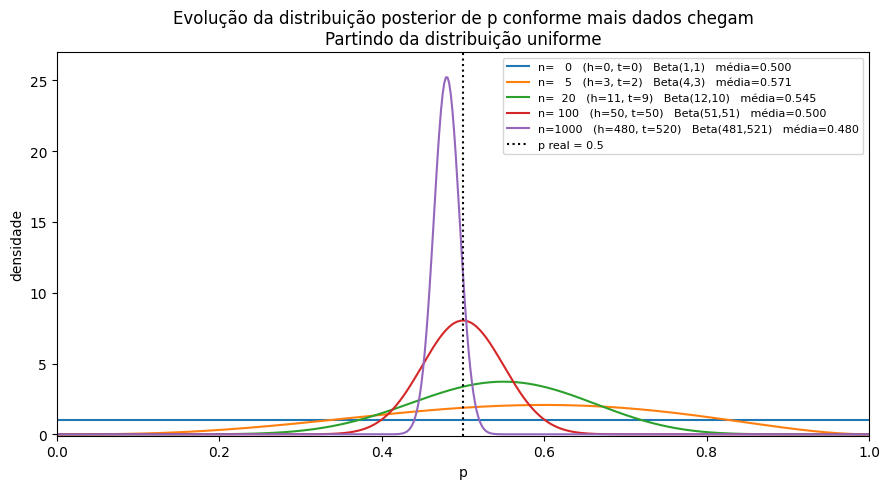

In [ ]:
def beta_pdf_(x, alpha, beta):
    if x <= 0 or x >= 1:
        return 0
    # usa log-gamma para evitar overflow quando alpha/beta sao grandes
    log_B = math.lgamma(alpha) + math.lgamma(beta) - math.lgamma(alpha + beta)
    log_pdf = (alpha - 1) * math.log(x) + (beta - 1) * math.log(1 - x) - log_B
    return math.exp(log_pdf)

random.seed(42)

# simula 1000 lancamentos de uma moeda honesta (p=0.5)
p_real      = 0.5
lancamentos = [1 if random.random() < p_real else 0 for _ in range(1000)]

# prior inicial: Beta(1,1) = uniforme (nenhuma opiniao previa)
alpha_0, beta_0 = 1, 1

# snapshots da distribuicao posterior
checkpoints = [0, 5, 20, 100, 1000]

plt.figure(figsize=(9, 5))
for n in checkpoints:
    h = sum(lancamentos[:n])   # caras vistas ate o momento
    t = n - h                  # coroas vistas ate o momento
    alpha_n, beta_n = alpha_0 + h, beta_0 + t # atualiza contagem
    ys = [beta_pdf_(x, alpha_n, beta_n) for x in xs]
    media = alpha_n / (alpha_n + beta_n)
    plt.plot(xs, ys, label=f"n={n:4d}   (h={h}, t={t})   Beta({alpha_n},{beta_n})   média={media:.3f}")

plt.axvline(p_real, color="black", linestyle=":", linewidth=1.5, label=f"p real = {p_real}")
plt.title("Evolução da distribuição posterior de p conforme mais dados chegam\nPartindo da distribuição uniforme")
plt.xlabel("p")
plt.ylabel("densidade")
plt.legend(fontsize=8)
plt.ylim(-0.1,27)
plt.xlim(0,1)

plt.tight_layout()
plt.show()

No gráfico acima podemos ver que:

- $n=0$: distribuição uniforme, todo valor de p entre 0 e 1 é igualmente provável. É literalmente _"eu não sei nada ainda"_.
- $n=5$: já começa a se deslocar e ganhar uma leve forma de sino, mas ainda bem larga (_"5 observações não dizem muito"_).
- $n=20$: mais estreita e mais alta, começando a se concentrar perto de 0,5.
- $n=100$: bem mais estreita, com a maior parte da massa de probabilidade já entre ~0,35 e ~0,6.
- $n=1000$: extremamente concentrada perto de 0,45-0,50. A essa altura, podemos ficar bastante confiantes de que $p$ está bem próximo de 0,5.

Note que a **altura da curva cresce** conforme $n$ também aumenta. Como a área sob cada curva é uma densidade de probabilidade, ela deve somar 1, e então, se a curva fica mais **estreita** (concentrada perto de um valor), ela precisa ficar mais **alta** pra compensar. Então:

- **estreito + alto**: _"estou bem confiante que $p$ está aqui"_
- **largo + baixo**: _"não tenho certeza, $p$ pode ser quase qualquer coisa"_.

Esse estreitamento progressivo é a versão bayesiana do TLC: conforme mais dados chegam, a incerteza sobre o parâmetro real vai diminuindo, e a distribuição vai se concentrando cada vez mais perto do valor verdadeiro (aqui nesse caso, $0,5$). Por isso que, com dados suficientes, a priori inicial deixa de importar.

Não importa se começou de $B(1,1)$ ou $B(30,10)$, depois de 1000 lançamentos reais as duas posteriores ficariam praticamente idênticas e igualmente estreitas, porque a "força" dos dados observados domina qualquer opinião inicial.

#### 7.5.3.2 Priores diferentes

Agora vamos imaginar a situação em que uma moeda é lançada 10 vezes, dando 3 caras e 7 coroas, ou seja, o dado observado é $p=0,3$.

Vamos considerar três priores diferentes:

- $B(1,1)$: distribuição uniforme, _"não sei nada ainda"_
- $B(20,20)$: razoávelmente honesta
- $B(30,10)$: com forte tendência para 'cara', uma tendência de $75\%$ na verdade.

No gráfico abaixo temos as distribuições a priores e posteriores:

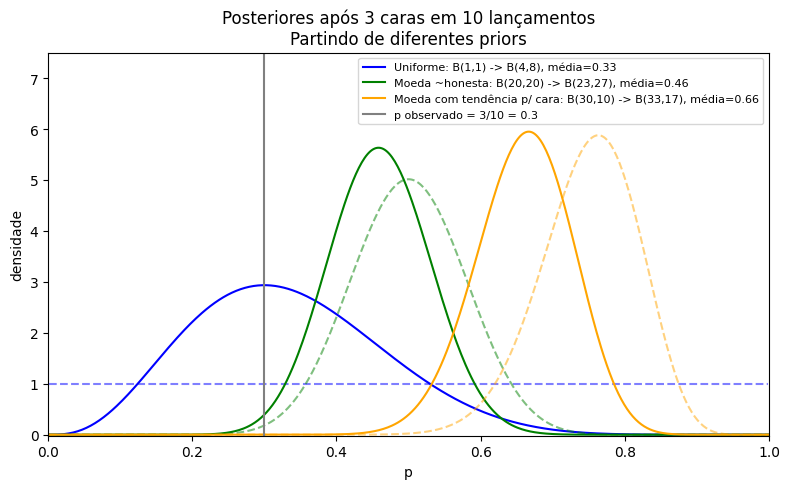

In [ ]:
# tres priores diferentes, atualizadas com h=3, t=7 (3 caras em 10 lancamentos)
h, t = 3, 7
priors = [
    ("Uniforme: B(1,1)", 1, 1, "blue"),
    ("Moeda ~honesta: B(20,20)", 20, 20, "green"),
    ("Moeda com tendência p/ cara: B(30,10)", 30, 10, "orange"),
]

plt.figure(figsize=(8, 5))
for label, alpha, beta, color in priors:
    alpha_post, beta_post = alpha + h, beta + t

    ys_prior   = [beta_pdf(x, alpha, beta) for x in xs]
    ys         = [beta_pdf(x, alpha_post, beta_post) for x in xs]
    media_post = alpha_post / (alpha_post + beta_post)

    plt.plot(xs, ys_prior, linestyle="--", color=color, alpha=0.5, label=None)
    plt.plot(xs, ys, color=color, label=f"{label} -> B({alpha_post},{beta_post}), média={media_post:.2f}")

plt.axvline(0.3, color="gray", linestyle="-", label="p observado = 3/10 = 0.3")
plt.title("Posteriores após 3 caras em 10 lançamentos\nPartindo de diferentes priors")
plt.xlabel("p")
plt.ylabel("densidade")
plt.legend(fontsize=8, loc="upper right")
plt.ylim(-0.02,7.5)
plt.xlim(0,1)

plt.tight_layout()
plt.show()

As três distribuições posteriores foram deslocadas em direção ao dado observado (linha pontilhada em $0,3$), mas a magnitude do deslocamento de cada uma delas dependeu do "palpite" inicial. Ou seja, estamos reformulando o "palpite" com o dado desses 10 lançamentos:

- Partindo da distribuição uniforme $B(1,1)$, como _"não sabíamos de nada"_, agora temos um novo palpite (posterior) que se aproxima mais da probabilidade inicial, com média $0,33$.
- A que partiu de $B(20,20)$, considerava a moeda como razoávelmente honesta, mas, após os 10 lançamentos, a distribuição posterior com média $0,46$ nos indica que a moeda tem uma leve tendência para 'coroa'.
- E para a que partiu de $B(30,10)$, que já assumia uma forte tendência para 'cara', temos uma nova distribuição com média $0,66$. Ainda acreditamos na tendência para 'cara', mas menos que antes.

A medida que lançamos a moeda mais vezes, a priori vai perdendo importância, até que eventualmente, temos (quase) a mesma distribuição posterior, não importa qual foi a priori inicial. Por exemplo, com 2000 lançamentos e 1000 caras, a priori $B(30,10)$ de 30+10=40 pseudo-observações se torna irrelevante perto de 2000 observações reais. A posterior vai ficar dominada pelos dados.

#### 7.5.3.3 A diferença filosófica para a abordagem frequentista

Voltando a falar do que muda em relação a abordagem frequentista, abaixo temos duas declarações:

- **Frequentista**: _"considerando que a moeda é honesta, veremos resultados tão extremos quanto esse apenas em 5% das vezes"_. Isso é uma afirmação sobre os **dados**, condicionada a uma hipótese sobre $p$. Não atribui probabilidade diretamente a $p$.
- **Bayesiana**: _"há $5\%$ de probabilidade de $p$ estar fora de $[0,49, 0,51]$"_. Isso é uma afirmação direta sobre $p$, tratado-a como algo que tem uma distribuição de probabilidade.

A questão aqui é que essa segunda frase exige aceitar a premissa filosófica de que faz sentido falar em "probabilidade" de um parâmetro fixo, e além disso, a escolha de prior é inevitavelmente subjetiva.

#### 7.5.3.4 Construindo o intervalo de confiança

Para construir o intervalo, precisamos da distribuição inteira, da mesma forma como fizemos com a Normal, é o mesmo raciocínio de `normal_two_sided_bounds()`, só que usando a distribuição Beta.

Queremos encontrar os dois pontos que deixam $2,5\%$ de área em cada cauda, usando a `ppf` (_percent point function_), que é a inversa da CDF (_cumulative distribution function_) da distribuição Beta.

In [ ]:
from scipy.stats import beta as beta_dist

def beta_two_sided_bound(probability, alpha, beta):
    tail_probability = (1 - probability) / 2
    lower_bound      = beta_dist.ppf(tail_probability, alpha, beta)
    upper_bound      = beta_dist.ppf(1 - tail_probability, alpha, beta)
    return lower_bound, upper_bound

In [ ]:
# B(30, 10)
alpha, beta           = 30, 10
h, t                  = 1000, 1000
alpha_post, beta_post = alpha + h, beta + t
media_post            = alpha_post / (alpha_post + beta_post)

lim_inf, lim_sup = beta_two_sided_bound(0.95, alpha_post, beta_post)
print(f"Há 5% de probabilidade de p estar fora de [{lim_inf:.3f},{lim_sup:.3f}] (média={media_post:.3f})")
print(f"Distância da média até o limite inferior: {media_post - lim_inf:.3f}")
print(f"Distância da média até o limite superior: {lim_sup - media_post:.3f}")

Há 5% de probabilidade de p estar fora de [0.483,0.527] (média=0.505)
Distância da média até o limite inferior: 0.022
Distância da média até o limite superior: 0.022


Aqui a média entra só implicitamente, ela influencia onde a distribuição está centrada, mas o intervalo em si vem da forma inteira da curva, capturada pelo CDF (e seu inverso), e depende apenas dos parâmetros $\alpha$ e $\beta$.

Um ponto que vale mencionar é que, ao contrário da distribuição Normal, a distribuição Beta não necessáriamente é simétrica em torno da média. Quando a distribuição é enviesada (como no caso abaixo, puxada em direção a 1), o intervalo "de área igual nas duas caudas" também fica levemente enviesado, não perfeitamente centrado na média.

In [ ]:
# B(30, 10)
alpha, beta           = 30, 10
h, t                  = 1000, 100
alpha_post, beta_post = alpha + h, beta + t
media_post            = alpha_post / (alpha_post + beta_post)

lim_inf, lim_sup = beta_two_sided_bound(0.95, alpha_post, beta_post)
print(f"Há 5% de probabilidade de p estar fora de [{lim_inf:.3f},{lim_sup:.3f}] (média={media_post:.3f})")
print(f"Distância da média até o limite inferior: {media_post - lim_inf:.3f}")
print(f"Distância da média até o limite superior: {lim_sup - media_post:.3f}")

Há 5% de probabilidade de p estar fora de [0.886,0.920] (média=0.904)
Distância da média até o limite inferior: 0.018
Distância da média até o limite superior: 0.016


### 7.5.4 Outro problema, outra distribuição

A Beta é adequada para problemas com 2 resultados possíveis, um evento de Bernoulli cuja soma é a Binomial.

Mas se estivéssemos falando de um prolema com $k$ resultados possíveis as coisas mudam um pouco. Nesse caso, teríamos a distribuição Categórica e ao invés da Binomial teríamos a Multinomial.

Assim como a Beta é conjugada posterior da Binomial, a função conjugada posterior da Multinomial é a Dirichlet, que é praticamente a generalização multidimensional da Beta. A Dirichlet não descreve a incerteza para um único $p$ (que automaticamente implica em $1-p$ para outro resultado possível), ela descreve a incerteza por um vetor de probabilidades ($p_{_1}, p_{_2}, ..., p_{_k}$), em que cada componente representa a probabilidade associada a um resultado possível e essas componentes devem somar $1$.

# Exemplo prático

## Dataset `marketing_ab`

Vamos praticar os conceitos vistos nesse capítulo utilizando o dataset [Marketing A/B Testing](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing).

- `user_id`: ID único de identificação dos usuários (numeric).
- `test_group`: Indica se usuário viu o anúncio ('ad') ou se faz parte do grupo de controle e não viu o anúncio ('psa') (categorical: ad, psa).
- `converted`: indica se o usuário comprou o produto (boolean).
- `total_ads`: Quantidade de anúncios vistos pelo usuário (numeric).
- `most_ads_day`: Dia da semana que usuário viu a maior quantiade de anúncios (categorical: Sunday, Monday, Tuesday, Wednesday, Thursday, Friday, Saturday).
- `most_ads_hour`: Hora do dia que usuário viu a maior quantidade de anúncios (numeric).

**O que é um teste A/B:** É um experimento randomizado em que diferentes versões de campanhas ou funcionalidades de um sistema são apresentadas a diferentes grupos de usuários ao mesmo tempo. O objetivo é avaliar o peso que a variável tem sobre o resultado final.

In [ ]:
import pandas as pd

df = pd.read_csv('datasets/marketing_ab.csv')
print(df.shape)
df.head()

(588101, 6)


,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        588101 non-null  int64 
 1   test_group     588101 non-null  object
 2   converted      588101 non-null  bool  
 3   total_ads      588101 non-null  int64 
 4   most_ads_day   588101 non-null  object
 5   most_ads_hour  588101 non-null  int64 
dtypes: bool(1), int64(3), object(2)
memory usage: 23.0+ MB


## Teste estatístico de hipóteses

### Aproximação Normal

Vamos começar verificando se a taxa de conversão do grupo de controle (ou seja, a taxa de conversão orgânica) é igual ao _benchmark_ histórico da empresa de $2\%$. Para isso formulamos a **hipótese nula** como: _"a taxa de conversão orgânica é igual ao benchmark histórico da empresa"_, então temos:

$$
\left\{
\begin{array}{ll}
H_0: p = 0,02 \\\\
H_1: p \neq 0,02
\end{array}
\right.
$$

Aqui cada usuário que participou do experimento será considerado um ensaio de $\text{Bernoulli}(p)$, em que o usuário convertido é $1$ e o não convertido é $0$. Então $X$ pode ser modelada como uma variável aleatória $\text{Binomial}(n,p)$ (a soma de $n$ usuários) e pode ser aproximada por uma função normal.

Para calcular a taxa de conversão observada precisamos da quantidade de usuários e quantos foram convertidos:

In [ ]:
qtd_agregadas = (
    df
    .groupby('test_group')
    .agg(
        n_group=("test_group", "count"),
        qtd_conv=("converted", "sum")
    )
    .assign(
        taxa_conv=lambda df: df.qtd_conv / df.n_group,
    )
)
qtd_agregadas

,n_group,qtd_conv,taxa_conv
test_group,,,
ad,564577,14423,0.025547
psa,23524,420,0.017854


In [ ]:
len(df)

588101

In [ ]:
# dados agregados do grupo PSA
n_psa    = qtd_agregadas.loc['psa']['n_group']   # tamanho do grupo PSA
conv_psa = qtd_agregadas.loc['psa']['qtd_conv']  # quantidade de conversoes no grupo PSA
p_psa    = qtd_agregadas.loc['psa']['taxa_conv'] # taxa de conversao do grupo PSA
# p_psa    = conv_psa / n_psa

print(f"Grupo PSA\nN = {n_psa}\nconversoes = {conv_psa}\ntaxa = {p_psa:.2%}")

Grupo PSA
N = 23524.0
conversoes = 420.0
taxa = 1.79%


In [ ]:
# aproximacao da distribuicao normal considerando hipotese nula eh verdadeira
p_h0          = 0.02 # condicao da hipotese nula
mu_0, sigma_0 = normal_approximation_to_binomial(n_psa, p_h0)

print(f"H_0: p_psa = {p_h0}\nmu_0 = {mu_0:.2f}\nsigma_0 = {sigma_0:.2f}")

H_0: p_psa = 0.02
mu_0 = 470.48
sigma_0 = 21.47


### Significância

Já estabelecemos nossa hipótese nula, então agora podemos encontrar o intervalo de confiança. Faremos isso primeiro definindo o nível de significância em $5\%$, para encontrar o nível de confiança:

In [ ]:
significancia = 0.05 # 5%
confianca     = 1 - significancia

print(f"Nível de confiança: {confianca:.0%}")

Nível de confiança: 95%


In [ ]:
# encontra os limites do intervalo de confianca, para significancia de 5%
lower_bound, upper_bound = normal_two_sided_bounds(confianca, mu_0, sigma_0)
print(f"Intervalo de confiança: [{lower_bound:.2f}, {upper_bound:.2f}]")

Intervalo de confiança: [428.39, 512.57]


Isso significa que:

> _"considerando que $H_0$ é verdadeira, se repetirmos o experimento muitas vezes, em $95\%$ das vezes a quantidade de usuários convertidos ($X$) vai estar dentro do intervalo $[428, 513]$"_

E, há uma probabilidade de $5\%$ de observarmos $X$ fora desse intervalo, e quando isso acontecer, vamos rejeitar $H_0$, mesmo ela sendo verdadeira (**erro tipo 1**). Ou seja, para uma significância de $5\%$, o teste indica o resultado correto em 19 de 20 vezes.

Se verificarmos o resultado observado ($420$), vamos notar que ele está fora desse intervalo, e isso já é **evidência suficiente para rejeitar $H_0$**. Mas além disso, vamos usar a `normal_cdf` para calcular a probabilidade de que a variável aleatória $X$ seja menor ou igual a $420$ (considerando $H_0$ como verdade) e comparar essa probabilidade com o nível de significância:

In [ ]:
# probabilidade de encontrar X<=420 se H_0 eh verdade
prob_ate_420 = normal_probability_below(420+0.5, mu_0, sigma_0)
print(f"P(conversoes <= 420 | H0 verdadeira) = {prob_ate_420:.2%}")

P(conversoes <= 420 | H0 verdadeira) = 1.00%


In [ ]:
prob_ate_420

0.009966066837405307

Lembrando que: como estamos aproximando uma variável **discreta** por uma variável **contínua** ($X$ só pode ser 0, 1, 2,..., não existe "420,5 usuários convertidos") devemos usar a "correção de continuidade".

Estamos interessados na probabilidade de $X$ estar naquela região, então para encontrar a probabilidade da variável aleatória ser menor ou igual a 420 inteiro, o corte na Normal precisa ser em 420,5.

Agora voltando a probabilidade calculada em $1\%$, isso siginifica que: _"considerando que $H_0$ sejá verdade, **em apenas $1\%$ das vezes que repetirmos o experimento, a variável aleatória terá um valor tão baixo quanto 420**"_. Comparando com a significância que definimos em $5\%$, podemos concluir que um resultado desse é muito raro. Portanto, temos mais uma evidência **para rejeitar $H_0$**.

### Poder do teste

O **poder do teste** é a probabilidade de detectar corretamente que a taxa observada de $1,79\%$ é diferente do _benchmark_ histórico de $2\%$. Ou seja, é a probabilidade de não ocorrer um **erro tipo 2**, quando falhamos em rejeitar a hipótese nula (sendo que ela é falsa).

Isso vai acontecer quando $X$ está dentro do intervalo de confiança (do _benchmark_ histórico) definido pela significância. Se $X$ cair dentro de $[428,513]$, mesmo que a taxa de conversão orgânica observada seja diferente do _benchmark_ histórico, deixo de rejeitar $H_0$ e isso é um **erro tipo 2**.

Nesse critério focamos na **capacidade de detectar que $H_0$ é falsa, quando ela de fato é falsa**. Aqui o raciocínio muda de lado, precisamos especificar o significado de uma $H_0$ falsa, então agora a pergunta é:

> _"Supondo que a taxa de conversão orgânica seja diferente do benchmark histórico (digamos, $H_{0'}: p = 0,0179$), com que frequência o teste (com o intervalo $[428,513]$ fixado pela significância) vai efetivamente perceber isso?"_

Em geral, **esse teste deve ser feito antes do experimento, ou então, ao interpretar um resultado que não rejeitou $H_0$**.

In [ ]:
# aproximacao da distribuicao normal considerando hipotese nula FALSA como verdadeira
p_h0_           = p_psa # assume a taxa observada como condicao da hipotese nula
mu_0_, sigma_0_ = normal_approximation_to_binomial(n_psa, p_h0_)

print(f"H_0': p_psa = {p_h0_}\nmu_0 = {mu_0_:.2f}\nsigma_0 = {sigma_0_:.2f}")

H_0': p_psa = 0.01785410644448223
mu_0 = 420.00
sigma_0 = 20.31


In [ ]:
# intervalo de confianca considerando H_0: p=0.02 como verdadeira
print(f"Intervalo de confiança: [{lower_bound:.2f}, {upper_bound:.2f}]")

Intervalo de confiança: [428.39, 512.57]


In [ ]:
type_2_prob = normal_probability_between(lower_bound, upper_bound, mu_0_, sigma_0_)
power = 1 - type_2_prob
print(f"4) Intervalo de aceitacao: [{lower_bound:.1f}, {upper_bound:.1f}]  |  Poder = {power:.4f}")

4) Intervalo de aceitacao: [428.4, 512.6]  |  Poder = 0.6603


In [ ]:
# type_2_prob: probabilidade de aceitar H_0 sendo que ela é falsa
# ou seja, probabilidade de X cair no intervalo de confianca do benchmark historico,
# quando a taxa de conversao eh diferente
type_2_prob = normal_probability_between(lower_bound, upper_bound, mu_0_, sigma_0_)
power = 1 - type_2_prob

print(f"P(erro tipo 2): {type_2_prob:.0%}")
print(f"Potência: {power:.0%}")

P(erro tipo 2): 34%
Potência: 66%


Esse resultado nos diz que: _"da forma como esse experimento foi desenhado, temos uma chance razoável (mas não altíssima) de rejeitar $H_0$ quando ela é realmente falsa"_.

### Teste unilateral

Inicialmente aplicamos um teste bilateral ao nosso problema, em que a hipótese nula avalia um valor exato $H_0: p = 0,02$ e qualquer desvio (para cima ou para baixo), é evidência contra $H_0$. Por isso o intervalo tinha duas bordas ($[428,513]$). Nesse caso a significância é divida entre os dois lados: $2,5\%$ na cauda de baixo e $2,5\%$ na cauda de cima.

Mas existe outro tipo de teste que pode ser feito, que dependendo da pergunta feita, talvez seja até mais adequado.

Se a pergunta que procuramos responder for algo como: _"a taxa de conversão orgânica piorou em relação ao benchmark histórico?"_. Então, não nos iteressa rejeitar $H_0$ se a taxa de conversão melhorou (se tem um desvio para cima). Nesse caso, podemos aplicar um teste unilateral, e que temos apenas uma fronteira de rejeição. Nesse caso, a significância ($5\%$) é alocada toda em apenas uma cauda.

Reformulando as hipóteses nula e alternativa:

$$
\left\{
\begin{array}{ll}
H_0: p \ge 0,02 \\\\
H_1: p < 0,02
\end{array}
\right.
$$

Assumindo $5\%$ de significância, quero determinar qual a fronteira

In [ ]:
# retorna z para o qual P(Z <= z) = 0.05
lo_unilateral = normal_upper_bound(0.05, mu_0, sigma_0)
lo_unilateral

np.float64(435.1608810502687)

In [ ]:
# retorna z para o qual P(Z >= z) = 0.95
lo_unilateral = normal_lower_bound(0.95, mu_0, sigma_0)
lo_unilateral

np.float64(435.1608810502687)

In [ ]:
from scipy.stats import norm
lo_unilateral = norm.ppf(0.05, mu_0, sigma_0)
lo_unilateral

np.float64(435.1607983867535)

In [ ]:
print(f"Teste bilateral: rejeita H_0 se X está fora de [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Teste unilateral: rejeita H_0 se X < {lo_unilateral:.2f}")

Teste bilateral: rejeita H_0 se X está fora de [428.39, 512.57]
Teste unilateral: rejeita H_0 se X < 435.16


No nosso caso, como observamos 420 usuários convertidos, rejeitamos $H_0$ em ambos os testes. Mas se tivéssemos entre 430 e 434 usuários convertidos, a escolha do tipo de teste influenciaria a decisão de rejeitar ou não a hipótese nula.

**Por isso, o tipo de teste deve ser escolhido antes da realização do experimento, ou antes de analisar os dados.**

### $p$-valor

Ao trabalhar com os $p$-values mudamos o raciocínio, em vez de pensar _**"onde está o corte"**_, agora avaliamos _**"quão extremo é o resultado que vejo"**_.

Já **temos** o $X$ observado, e perguntamos diretamente: _"supondo $H_0$ verdadeira, qual a probabilidade de ver um resultado tão extremo quanto esse?"_

Em vez de comparar **$X$ com uma fronteira fixa**, comparamos **uma probabilidade com o nível de significância**.

Como defini a significância em $5\%$, o $p$-valor diz: **"se $H_0$ for verdadeira, 5% dos experimentos vão produzir, por puro acaso, _um resultado tão extremo quanto o observado_"**.

A região abaixo da curva normal que corresponde a esses $5\%$ é tudo aquilo que fica fora do intervalo $[428,513]$ (referente ao exemplo que estamos tratando). No teste bilateral, essa probabilidade se divide entre as duas caudas, $2,5\%$ para cada lado.

Quando calculamos o $p$-valor de um $X$ observado obtemos a _**"área abaixo da curva (nas duas caudas) que fica além desse $X$ observado"**_. Então, o resultado pode ser intepretado de duas formas:

- $p$-valor $< 5\%$ → $X$ está fora do intervalo de confiança (é um resultado mais extremo) → sobra **menos** de $5\%$ de área para valores mais extremos que $X$ → **tenho evidência para rejeitar $H_0$**
- $p$-valor $> 5\%$ → $X$ está dentro do intervalo (é um resultado mais próximo da média) → sobra **mais** de $5\%$ de área para valores mais extremos que $X$ → **NÃO tenho evidência para rejeitar $H_0$**

Então, vamos calcular o teste bilateral da conversão orgânica, avaliando se é igual ao _benchmark_ histórico:

In [ ]:
# probabilidade de observar um resultado tao extremo quanto o observado, H_0 eh verdade
p_valor_bilateral = two_sided_p_value(conv_psa + 0.5, mu_0, sigma_0)
print(f"p-valor bilateral = {p_valor_bilateral:.2%}")

# 6) p-valor bilateral = 0.019932  |  unilateral = 0.009966

p-valor bilateral = 1.99%


In [ ]:
p_valor_bilateral

0.019932133674810615

In [ ]:
significancia

0.05

In [ ]:
p_valor_bilateral < significancia

True

In [ ]:
conv_psa

np.float64(420.0)

Esse $p$-valor calculado significa que em apenas $1,99\%$ das vezes que o experimento for realizado, será possível observar um resultado tão extremo quanto 420. Como é uma "área" menor que os $5\%$ da significância, então temos evidência suficiente para rejeitar $H_0$.

Para aplicar o teste unilateral, basta dividir o $p$-valor bilateral por 2:

In [ ]:
p_valor_bilateral / 2

0.009966066837405307

In [ ]:
print(inspect.getsource(two_sided_p_value))

def two_sided_p_value(x: float, mu: float = 0, sigma: float = 1) -> float:
    """
    Retorna a probabilidade de ver um resultado tão extremo (ou mais) que x
    """
    if x >= mu:
        # x eh maior do que a media, entao coroa eh qualquer valor maior que x
        return 2 * normal_probability_above(x, mu, sigma)
    else:
        # x eh menor do que a media, entao cara eh qualquer valor menor que x
        return 2 * normal_probability_below(x, mu, sigma)



### Intervalos de confiança

Vamos contruir um intervalo de confiança para a taxa de conversão $p_{_{PSA}}$, de acordo com o valor observado $X_{PSA}$ (que agora é um fato que conhecido, já aconteceu, já foi medido).

Ou seja, agora a taxa de conversão $p_{_{PSA}}$ não é mais um valor fixo, mas uma variável, e a pergunta que fazemos é: "**dado que $X_{PSA}=420$, quais valores de $p_{_{PSA}}$ são plausíveis?**"

Como já discutido anteriormente, podemos estimar $p_{_{PSA}}$ de acordo com a quantidade de usuários convertidos, usando como aproximação $\hat{p}_{_{PSA}} = \frac{\text{conversões PSA}}{n_{_{PSA}}} = \frac{420}{23524} = 0,017854$, desde que $n$ seja grande e $\hat{p}_{_{PSA}}$ não esteja muito perto de $0$ e $1$.

In [ ]:
p_psa

np.float64(0.01785410644448223)

In [ ]:
print(f"Grupo PSA\nN = {n_psa}\nconversoes = {conv_psa}\ntaxa = {p_psa:.2%}")

Grupo PSA
N = 23524.0
conversoes = 420.0
taxa = 1.79%


In [ ]:
# aproximacao normal para experimento que observamos x=420
p_hat_psa    = p_psa
mu_ic_psa    = p_hat_psa
sigma_ic_psa = math.sqrt(p_hat_psa * (1 - p_hat_psa) / n_psa)

In [ ]:
# calcula intervalo de confianca em torno de p_hat, com 95% de confianca
lower_bound_ic_psa, upper_bound_ic_psa = normal_two_sided_bounds(0.95, mu_ic_psa, sigma_ic_psa)
print(f"Intervalo de confiança (grupo PSA): [{lower_bound_ic_psa:.2%}, {upper_bound_ic_psa:.2%}]")

Intervalo de confiança (grupo PSA): [1.62%, 1.95%]


Aplicamos a aproximação normal considerando o $X$ observado e calculamos o intervalo em que o verdadeiro $p$ se encontra com $95\%$ de confiança.

Aqui precisamos entender que o que varia ao longo dos experimentos é o intervalo, que estará sempre centrado no valor de $X$ observado. A aleatoriedade está no intervalo, não em $p$.

Quando observamos $X = 420$ conversões, o intervalo calculado é $[1,62\%, 1,95\%]$. Avaliando a hipótese nula $H_0: p=2%$, vemos que o intervalo de confiança **não contém** $p=2\%$. Ou seja, temos evidência para rejeitar $H_0$ e dizer que a taxa de conversão orgânica dessa campanha não é igual ao _benchmark_ histórico da empresa.

Também podemos calcular o intervalo de confiança para a taxa de conversão do grupo que assistiu anúncios $p_{_{AD}}$, quando observamos $X_{AD}=14.423$ usuários convertidos:

In [ ]:
qtd_agregadas

,n_group,qtd_conv,taxa_conv
test_group,,,
ad,564577,14423,0.025547
psa,23524,420,0.017854


In [ ]:
n_ad    = qtd_agregadas.loc['ad']['n_group']  # tamanho do grupo AD
conv_ad = qtd_agregadas.loc['ad']['qtd_conv'] # quantidade de conversoes no grupo AD
p_ad    = conv_ad / n_ad                      # taxa de conversao do grupo AD

print(f"Grupo AD\nN = {n_ad}\nconversoes = {conv_ad}\ntaxa = {p_ad:.2%}")

Grupo AD
N = 564577.0
conversoes = 14423.0
taxa = 2.55%


In [ ]:
# aproximacao normal para experimento que observamos x=14423
p_hat_ad    = p_ad
mu_ic_ad    = p_hat_ad
sigma_ic_ad = math.sqrt(p_hat * (1 - p_hat) / n_ad)

In [ ]:
# calcula intervalo de confianca em torno de p_hat, com 95% de confianca
lower_bound_ic_ad, upper_bound_ic_ad = normal_two_sided_bounds(0.95, mu_ic_ad, sigma_ic_ad)
print(f"Intervalo de confiança (grupo AD): [{lower_bound_ic_ad:.2%}, {upper_bound_ic_ad:.2%}]")

Intervalo de confiança (grupo AD): [2.42%, 2.68%]


### Teste A/B

No dataset que estamos utilizando existem dois grupos diferentes e queremos determinar se a taxa de conversão em um dos grupos é maior que no outro. Fazendo as contas, encontramos que um grupo possui taxa de conversão maior que o outro. Mas ainda não sabemos se essa diferença é estatísticamente significativa. Esso é o clássico caso de um teste A/B.

A pergunta que fazemos é no sentido de que as taxas de conversão são iguais, ou seja, se _"os dois anúncios são igualmente efetivos"_. Para avaliar essa pergunta definimos uma terceira variável normal, a diferença $(p_{_{AD}} - p_{_{PSA}})$, e formulamos as seguintes hipóteses:

$$
\left\{
\begin{array}{ll}
H_0: p_{_{AD}} - p_{_{PSA}} = 0 \\\\
H_1: p_{_{AD}} - p_{_{PSA}} \neq 0
\end{array}
\right.
$$

#### $z$-score

Como estamos trabalhando com uma terceira distribuição, a diferença $(p_{_{AD}} - p_{_{PSA}})$, vamos calcular o $z$-score utilizando a expressão abaixo:

$$Z = \frac{\hat{p}_{_{AD}} - \hat{p}_{_{PSA}}}{\sqrt{\sigma^2_{_{PSA}} + \sigma^2_{_{AD}}}}$$

que veio da padronização da distribuição normal, onde o numerador é o **valor observado** ($X=2,55\% - 1,79\% = 0,77\%$) e o denominador é **desvio-padrão da variável observada**. O o valor esperado quando $H_0$ for verdade é zero, e lembrando que o $z$-score me diz:

> _"quantos desvios-padrão de distância da média $\mu$ (esperada sob $H_0$) está o valor observado $X$"_

Finalmente, vamos aplicar o teste utilizando as ferramentas que já contruímos, primeiro calculando o $z$-score:

In [ ]:
print(inspect.getsource(estimated_parameters))

def estimated_parameters(N: int, n: int) -> Tuple[float, float]:
    p     = n / N
    sigma = math.sqrt(p * (1 - p) / N)
    return p, sigma



In [ ]:
print(inspect.getsource(a_b_test_statistic))

def a_b_test_statistic(N_A: int, n_A: int, N_B: int, n_B: int) -> float:
    p_A, sigma_A = estimated_parameters(N_A, n_A)
    p_B, sigma_B = estimated_parameters(N_B, n_B)
    return (p_B - p_A) / math.sqrt(sigma_A ** 2 + sigma_B ** 2)



In [ ]:
print(f"Grupo PSA\nN = {n_psa:.0f}\nconversoes = {conv_psa:.0f}\ntaxa = {p_psa:.2%}")
print(f"\nGrupo AD\nN = {n_ad:.0f}\nconversoes = {conv_ad:.0f}\ntaxa = {p_ad:.2%}")

Grupo PSA
N = 23524
conversoes = 420
taxa = 1.79%

Grupo AD
N = 564577
conversoes = 14423
taxa = 2.55%


In [ ]:
# valor observado para a terceira variavel (diferenca entre as duas distribuicoes)
print(f"{abs(p_ad - p_psa):.2%}")

0.77%


In [ ]:
z_ab = a_b_test_statistic(n_psa, conv_psa, n_ad, conv_ad)
z_ab

np.float64(8.657336478930567)

In [ ]:
z_ba = a_b_test_statistic(n_ad, conv_ad, n_psa, conv_psa)
z_ba

np.float64(-8.657336478930567)

In [ ]:
abs(z_ab) == abs(z_ba) # a distribuicao normal eh simetrica em torno de sua media

np.True_

O $z$-score nos diz que a diferença observada $X=0,77\%$ está a $8,66$ desvios padrão de distância da média esperada sob $H_0$ (que no caso é zero). Ou seja, é um valor bastante alto.

Ao lembrarmos da escala de desvios padrão, vemos que este valor está bem além do intervalo $[-3\sigma, 3\sigma]$, fora do qual apenas $0,3\%$ dos resultados possíveis se encontram. Isso nos sinaliza que o resultado observado é praticamente impossível de acontecer, o que podemos considerar evidência suficiente para rejeitar $H_0$. Ou seja, **as duas taxas de conversão não são iguais e podemos afirmar que uma é maior que a outra**.

#### $p$-valor

Podemos ainda calcular a probabilidade de observar essa diferença de $0,77\%$ pontos percentuais entre as duas taxas de conversão (ou um resultado tão extremo quanto), se os dois anúncios são igualmente efetivos (ou seja, se $H_0$ é verdade). E ela é dada pelo $p$-valor:

In [ ]:
print(inspect.getsource(two_sided_p_value))

def two_sided_p_value(x: float, mu: float = 0, sigma: float = 1) -> float:
    """
    Retorna a probabilidade de ver um resultado tão extremo (ou mais) que x
    """
    if x >= mu:
        # x eh maior do que a media, entao coroa eh qualquer valor maior que x
        return 2 * normal_probability_above(x, mu, sigma)
    else:
        # x eh menor do que a media, entao cara eh qualquer valor menor que x
        return 2 * normal_probability_below(x, mu, sigma)



In [ ]:
two_sided_p_value(z_ab)

0.0

Um $p$-valor igual a zero (não é exatamente zero, porque já vi em outros notebooks desse dataset, mas é muito pequeno) é tão extremo que podemos considerar esse resultado como "impossível sob $H_0$", o que nos fornece mais evidência de que a taxa de conversão em um dos grupos é maior que o outro.

#### Desbalanceamento entre os grupos

In [ ]:
df['test_group'].value_counts(normalize=True)

,proportion
test_group,
ad,0.96
psa,0.04


Olhando a distribuição dos grupos, notamos que existe desbalanceamento entre eles, com o grupo de AD representando $96\%$ da base. Mas em que isso nos afeta?

O desbalanceamento dos grupos nos afeta na precisão, temos um problema de **desperdício de poder estatístico**. Como estamos usando a aproximação Normal, o $N$ de cada grupo é embutido no desvio padrão $\sigma = \sqrt{p(1-p)}$:

- Quanto menor o $N$ → maior o $\sigma$ → menos precisão
- Quanto maior o $N$ → menor o $\sigma$ → mais precisão

Vamos simular o cenário em que a divisão dos grupos fosse igual, ou seja, teríamos a razão 50/50 ao invés de 96/4.

In [ ]:
print(inspect.getsource(estimated_parameters))

def estimated_parameters(N: int, n: int) -> Tuple[float, float]:
    p     = n / N
    sigma = math.sqrt(p * (1 - p) / N)
    return p, sigma



In [ ]:
print(inspect.getsource(a_b_test_statistic))

def a_b_test_statistic(N_A: int, n_A: int, N_B: int, n_B: int) -> float:
    p_A, sigma_A = estimated_parameters(N_A, n_A)
    p_B, sigma_B = estimated_parameters(N_B, n_B)
    return (p_B - p_A) / math.sqrt(sigma_A ** 2 + sigma_B ** 2)



In [ ]:
# simula tamanho dos grupos se base fosse "perfeitamente" balanceada
N_50_50 = int(len(df) / 2)
N_50_50

294050

In [ ]:
# calcula z-score se base fosse "perfeitamente" balanceada, grupos com tamanho igual
((p_ad - p_psa) / math.sqrt(
    (math.sqrt(p_psa * (1 - p_psa) / N_50_50)) ** 2
    + (math.sqrt(p_ad * (1 - p_ad) / N_50_50)) ** 2
))

np.float64(20.25082277625103)

In [ ]:
# z-score calculado nos dados originais, com grupos desbalanceados
z_ab = a_b_test_statistic(n_psa, conv_psa, n_ad, conv_ad)
z_ab

np.float64(8.657336478930567)

Aqui fica claro que se a base fosse perfeitamente balanceada, teríamos mais "força estatística" ($20,25$ contra $8,66$) para detectar a mesma diferença real.

#### Intervalos de confiança

A pouco, calculamos intervalos de confiança para as taxas de conversão de cada grupo (de forma isolada), acordo com os dados observados e assumindo o nível de confiança em $95\%$:



In [ ]:
print(f"Intervalo de confiança (grupo PSA): [{lower_bound_ic_psa:.2%}, {upper_bound_ic_psa:.2%}]")
print(f"Intervalo de confiança (grupo AD):  [{lower_bound_ic_ad:.2%}, {upper_bound_ic_ad:.2%}]")

Intervalo de confiança (grupo PSA): [1.62%, 1.95%]
Intervalo de confiança (grupo AD):  [2.42%, 2.68%]


Podemos ver claramente que **os dois intervalos não se sobrepõem**, o que significa que **não existe um único valor de que seja simultaneamente plausível para os dois grupos**.

Se a taxa de conversão nos dois grupos fosse realmente igual, devíamos esperar alguma faixa em comum nos dois intervalos, mas isso não acontece aqui.

Mas esse critério é uma **heurística conservadora, não um substituto do teste formal de diferença de proporções**. O teste A/B formal é mais sensível que essa checagem de sobreposição dos intervalos, é totalmente possível encontrarmos cenários em que exista uma "pequena" sobreposição dos intervalos e o teste formal indica uma diferença estatísticamente significativa entre as taxas analisadas.

### Inferência Bayesiana

Vamos responder a mesma pergunta do Teste A/B, mas agora no "estilo" bayesiano. Queremos saber

> _**"qual a probabilidade de que $p_{_{AD}}$ seja maior que $p_{_{PSA}}$, de acordo com os dados observados?"**_

#### Passo 1: Difinição do Prior

Como ainda "não vimos os dados", qualquer taxa de convesão entre $0\%$ e $100\%$ é igualmente plausível. Portanto, começamos com um prior uniforme $\text{B}(1,1)$:

In [ ]:
# parte do prior uniforme B(1,1)
alpha_prior, beta_prior = 1, 1

#### Passo 2: Atualização da distribuição com dados observados

Após ver os dados, aplicamos a regra de conjugação ($\alpha + \text{h}$, $\beta + \text{t}$) e atualizamos a distribuição Beta, para cada grupo. Agora temos a distribuição posterior:

In [ ]:
alpha_psa_post, beta_psa_post = alpha_prior + conv_psa, beta_prior + (n_psa - conv_psa) # B(420, 23105)
alpha_ad_post, beta_ad_post   = alpha_prior + conv_ad, beta_prior + (n_ad - conv_ad)    # B(14424, 550155)

# alpha_psa_post, beta_psa_post = 1 + 420,   1 + (23524 - 420)    # B(420, 23105)
# alpha_ad_post, beta_ad_post   = 1 + 14423, 1 + (564577 - 14423) # B(14424, 550155)

Calculamos a taxa de conversão observada e também seu intervalo de confiança:

In [ ]:
print(inspect.getsource(beta_two_sided_bound))

def beta_two_sided_bound(probability, alpha, beta):
    tail_probability = (1 - probability) / 2
    lower_bound      = beta_dist.ppf(tail_probability, alpha, beta)
    upper_bound      = beta_dist.ppf(1 - tail_probability, alpha, beta)
    return lower_bound, upper_bound



In [ ]:
media_post_psa           = alpha_psa_post / (alpha_psa_post + beta_psa_post)
lim_inf_psa, lim_sup_psa = beta_two_sided_bound(0.95, alpha_psa_post, beta_psa_post)

print("Grupo PSA")
print(f"- Há 5% de probabilidade da taxa de conversão estar fora de [{lim_inf_psa:.6f},{lim_sup_psa:.6f}] (média={media_post_psa:.6f})")
print(f"- Distância da média até o limite inferior: {media_post_psa - lim_inf_psa:.6f}")
print(f"- Distância da média até o limite superior: {lim_sup_psa - media_post_psa:.6f}")

Grupo PSA
- Há 5% de probabilidade da taxa de conversão estar fora de [0.016240,0.019628] (média=0.017895)
- Distância da média até o limite inferior: 0.001655
- Distância da média até o limite superior: 0.001732


In [ ]:
media_post_ad           = alpha_ad_post / (alpha_ad_post + beta_ad_post)
lim_inf_ad, lim_sup_ad = beta_two_sided_bound(0.95, alpha_ad_post, beta_ad_post)

print("Grupo AD")
print(f"- Há 5% de probabilidade da taxa de conversão estar fora de [{lim_inf_ad:.6f},{lim_sup_ad:.6f}] (média={media_post_ad:.6f})")
print(f"- Distância da média até o limite inferior: {media_post_ad - lim_inf_ad:.6f}")
print(f"- Distância da média até o limite superior: {lim_sup_ad - media_post_ad:.6f}")

Grupo AD
- Há 5% de probabilidade da taxa de conversão estar fora de [0.025138,0.025961] (média=0.025548)
- Distância da média até o limite inferior: 0.000410
- Distância da média até o limite superior: 0.000413


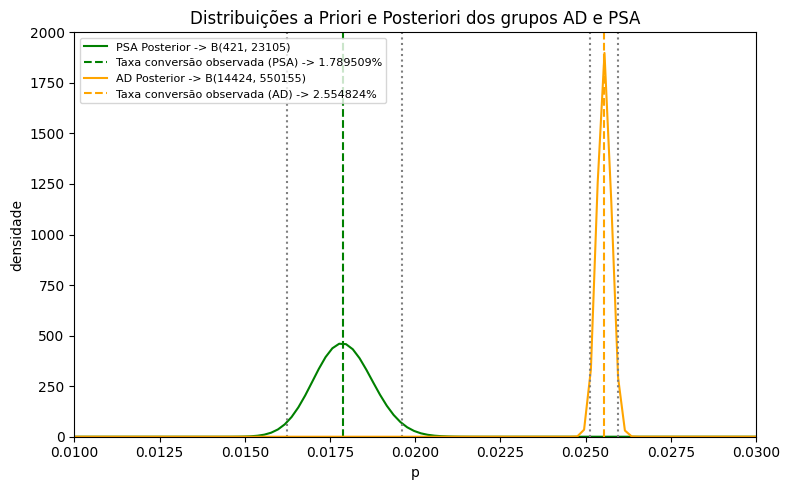

In [ ]:
xs_ = np.linspace(0.001, 0.999, 5000)
distribuicoes = [
    ("PSA Posterior", alpha_psa_post, beta_psa_post, "green"),
    ("AD Posterior", alpha_ad_post, beta_ad_post, "orange"),
]

plt.figure(figsize=(8, 5))
for label, alpha, beta, color in distribuicoes:
    ys = [beta_pdf_(x, alpha, beta) for x in xs_]
    plt.plot(xs_, ys, color=color, label=f"{label} -> B({int(alpha)}, {int(beta)})")

    # quanto mais medidas sao feitas, mais a distribuicao converge para a taxa observada
    taxa_conversao = alpha / (alpha + beta)
    plt.axvline(taxa_conversao, color=color, linestyle="--",
                label=f"Taxa conversão observada ({label.replace(' Posterior', '')}) -> {taxa_conversao:2%}")

    # calcula o intervalo de confinca da taxa de conversao de cada distribuicao
    lim_inf, lim_sup = beta_two_sided_bound(0.95, alpha, beta)
    plt.axvline(lim_inf, color="gray", linestyle=":")
    plt.axvline(lim_sup, color="gray", linestyle=":")

plt.title("Distribuições a Priori e Posteriori dos grupos AD e PSA")
plt.xlabel("p")
plt.ylabel("densidade")
plt.legend(fontsize=8, loc="upper left")
plt.ylim(-0.02,2000)
plt.xlim(0.01,0.03)

plt.tight_layout()
plt.show()

#### Passo 3: Calcular a probabilidade

Ao contrário da função Normal, em que podiamos calcular analíticamente a diferença entre duas variáveis normais, para a distribuição Beta, não temos uma fórmula fechada e simples para calcular a diferença entre duas variáveis Beta. Não podemos fazer algo como "Beta menos Beta = outra distribuição conhecida".

A solução aqui é aplicar o **método de Monte Carlo**: _simulamos o processo repetidamente, usando números aleatórios, e usamos a frequência/média observada como estimativa da resposta verdadeira._

Vamos fazer a seguinte simulação: aleatóriamente geramos pares de valores plausíveis para as duas distribuições e contamos em quantos desses pares $p_{_{AD}} > p_{_{PSA}}$. Ao calcular a razão dessa contagem pelo número de pares sorteados, chegamos na probabilidade $P(p_{_{AD}} > p_{_{PSA}})$, que é uma aproximação numérica de uma integral que seria complicada de resolver analiticamente.

Faremos isso usando a função `rvs(alpha, beta, size)` (**r**andom **v**ariate**s**), que gera valores aleatórios seguindo a distribuição Beta definida por $\alpha$ e $\beta$. Isso será feito para os dois grupos, e ao final, quando tivermos um _array_ para cada distribuição, vamos comparar os respectivos itens:

In [ ]:
# importante passar seeds diferentes, para que os numeros gerados sejam venham de sequencias aleatorias desconectadas e nao estejam correlacionados
amostras_psa   = beta_dist.rvs(alpha_psa_post, beta_psa_post, size=200_000, random_state=123)
amostras_ad    = beta_dist.rvs(alpha_ad_post, beta_ad_post, size=200_000, random_state=987)
prob_ad_melhor = np.mean(amostras_ad > amostras_psa)

print(f"P(p_ad > p_psa | dados) = {prob_ad_melhor:.4%}")

P(p_ad > p_psa | dados) = 100.0000%
